In [16]:
import numpy as np
import matplotlib.pyplot as plt
from UPVfab_tools import open_file, filter_wavelength

# Functions

In [ ]:
def coupling_1x2(wavelength_dut, power_dut_11, power_dut_12, power_wg, dut_name):
    ######################################################################################################################
    # Function to calculate coupling coefficients and loss for a 1x2 coupler
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut_11: array of power values for output 1 of the DUT
    # - power_dut_12: array of power values for output 2 of the DUT
    # - power_wg: 2D array of power values for the waveguide reference measurement (each row corresponds to a different measurement)
    # - dut_name: string with the name of the DUT (for plot titles)
    # Outputs:
    # - None (plots the coupling coefficients and loss)
    ######################################################################################################################

    # Calculate coupling coefficients for both outputs
    k1 = 10**((power_dut_11)/10) / (10**((power_dut_11)/10) + 10**((power_dut_12)/10))
    k2 = 10**((power_dut_12)/10) / (10**((power_dut_11)/10) + 10**((power_dut_12)/10))

    # Calculate average power from waveguide reference measurements and compute loss
    power_avg = np.mean(power_wg, axis=0)
    loss = (10**((power_dut_11)/10) + 10**((power_dut_12)/10))/10**((power_avg)/10)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(wavelength_dut, k1, label=r'$\kappa$', color='blue')
    axs[0].plot(wavelength_dut, k2, label=r'1-$\kappa$', color='red')

    axs[0].set_ylim(0, 1)
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("Coupling Coefficient")
    axs[0].set_title(f"Coupling Coefficients for {dut_name}")
    axs[0].legend()
    axs[0].grid()
    
    axs[1].plot(wavelength_dut, loss)
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("Loss")
    axs[1].set_title(f"Coupling Loss for {dut_name}")
    axs[1].grid()

    plt.tight_layout()
    plt.show()
    
    return None

def coupling_2x2(wavelength_dut, power_dut_11, power_dut_12, power_dut_21, power_dut_22, power_wg, dut_name):
    #######################################################################################################################
    # Function to calculate coupling coefficients and loss for a 2x2 coupler
    # Inputs:
    # - wavelength_dut: array of wavelength values for the DUT
    # - power_dut_11: array of power values for output 1 of input 1 of the DUT
    # - power_dut_12: array of power values for output 2 of input 1 of the DUT
    # - power_dut_21: array of power values for output 1 of input 2 of the DUT
    # - power_dut_22: array of power values for output 2 of input 2 of the DUT
    # - power_wg: 2D array of power values for the waveguide reference measurement (each row corresponds to a different measurement)
    # - dut_name: string with the name of the DUT (for plot titles)
    # Outputs:
    # - None (plots the coupling coefficients and loss)
    #######################################################################################################################
    
    k1 = 10**((power_dut_11)/10) / (10**((power_dut_11)/10) + 10**((power_dut_12)/10))
    k2 = 10**((power_dut_12)/10) / (10**((power_dut_11)/10) + 10**((power_dut_12)/10))

    k3 = 10**((power_dut_21)/10) / (10**((power_dut_21)/10) + 10**((power_dut_22)/10))
    k4 = 10**((power_dut_22)/10) / (10**((power_dut_21)/10) + 10**((power_dut_22)/10))

    power_avg = np.mean(power_wg, axis=0)
    loss_1 = (10**((power_dut_11)/10) + 10**((power_dut_12)/10))/10**((power_avg)/10)
    loss_2 = (10**((power_dut_21)/10) + 10**((power_dut_22)/10))/10**((power_avg)/10)

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    axs[0].plot(wavelength_dut, k1, label=r'$\kappa$ (Input 1)', color='blue')
    axs[0].plot(wavelength_dut, k2, label=r'1-$\kappa$ (Input 1)', alpha=0.4, color='blue')

    axs[0].plot(wavelength_dut, k3, label=r'$\kappa$ (Input 2)', color='red')
    axs[0].plot(wavelength_dut, k4, label=r'1-$\kappa$ (Input 2)', alpha=0.4, color='red')
    
    axs[0].set_ylim(0, 1)
    axs[0].set_xlabel("Wavelength (nm)")
    axs[0].set_ylabel("Coupling Coefficient")
    axs[0].set_title(f"Coupling Coefficients for {dut_name}")
    axs[0].legend(fontsize=9)
    axs[0].grid()

    axs[1].plot(wavelength_dut, loss_1, label='Input 1')
    axs[1].plot(wavelength_dut, loss_2, label='Input 2')
    axs[1].set_xlabel("Wavelength (nm)")
    axs[1].set_ylabel("Loss")
    axs[1].set_title(f"Coupling Loss for {dut_name}")
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()
    
    return None

# Initialization

In [18]:
# ASE1 range
wl_0 = 1530 
wl_1 = 1600

In [19]:
### R1 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p0.txt"
wavelength_p0_r1, power_p0_r1 = open_file(file_path)
wavelength_p0_r1, power_p0_r1 = filter_wavelength(wavelength_p0_r1, power_p0_r1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p1.txt"
wavelength_p1_r1, power_p1_r1 = open_file(file_path)
wavelength_p1_r1, power_p1_r1 = filter_wavelength(wavelength_p1_r1, power_p1_r1, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p2.txt"
wavelength_p2_r1, power_p2_r1 = open_file(file_path)
wavelength_p2_r1, power_p2_r1 = filter_wavelength(wavelength_p2_r1, power_p2_r1, wl_0, wl_1)

### R4 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p0.txt"
wavelength_p0_r4, power_p0_r4 = open_file(file_path)
wavelength_p0_r4, power_p0_r4 = filter_wavelength(wavelength_p0_r4, power_p0_r4, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p1.txt"
wavelength_p1_r4, power_p1_r4 = open_file(file_path)
wavelength_p1_r4, power_p1_r4 = filter_wavelength(wavelength_p1_r4, power_p1_r4, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p2.txt"
wavelength_p2_r4, power_p2_r4 = open_file(file_path)
wavelength_p2_r4, power_p2_r4 = filter_wavelength(wavelength_p2_r4, power_p2_r4, wl_0, wl_1)

### R8 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p0.txt"
wavelength_p0_r8, power_p0_r8 = open_file(file_path)
wavelength_p0_r8, power_p0_r8 = filter_wavelength(wavelength_p0_r8, power_p0_r8, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p1.txt"
wavelength_p1_r8, power_p1_r8 = open_file(file_path)
wavelength_p1_r8, power_p1_r8 = filter_wavelength(wavelength_p1_r8, power_p1_r8, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p2.txt"
wavelength_p2_r8, power_p2_r8 = open_file(file_path)
wavelength_p2_r8, power_p2_r8 = filter_wavelength(wavelength_p2_r8, power_p2_r8, wl_0, wl_1)

### R9 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p0.txt"
wavelength_p0_r9, power_p0_r9 = open_file(file_path)
wavelength_p0_r9, power_p0_r9 = filter_wavelength(wavelength_p0_r9, power_p0_r9, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p1.txt"
wavelength_p1_r9, power_p1_r9 = open_file(file_path)
wavelength_p1_r9, power_p1_r9 = filter_wavelength(wavelength_p1_r9, power_p1_r9, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p2.txt"
wavelength_p2_r9, power_p2_r9 = open_file(file_path)
wavelength_p2_r9, power_p2_r9 = filter_wavelength(wavelength_p2_r9, power_p2_r9, wl_0, wl_1)

### R13 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p0.txt"
wavelength_p0_r13, power_p0_r13 = open_file(file_path)
wavelength_p0_r13, power_p0_r13 = filter_wavelength(wavelength_p0_r13, power_p0_r13, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p1.txt"
wavelength_p1_r13, power_p1_r13 = open_file(file_path)
wavelength_p1_r13, power_p1_r13 = filter_wavelength(wavelength_p1_r13, power_p1_r13, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p2.txt"
wavelength_p2_r13, power_p2_r13 = open_file(file_path)
wavelength_p2_r13, power_p2_r13 = filter_wavelength(wavelength_p2_r13, power_p2_r13, wl_0, wl_1)

### R16 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p0.txt"
wavelength_p0_r16, power_p0_r16 = open_file(file_path)
wavelength_p0_r16, power_p0_r16 = filter_wavelength(wavelength_p0_r16, power_p0_r16, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p1.txt"
wavelength_p1_r16, power_p1_r16 = open_file(file_path)
wavelength_p1_r16, power_p1_r16 = filter_wavelength(wavelength_p1_r16, power_p1_r16, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p2.txt"
wavelength_p2_r16, power_p2_r16 = open_file(file_path)
wavelength_p2_r16, power_p2_r16 = filter_wavelength(wavelength_p2_r16, power_p2_r16, wl_0, wl_1)

### R20 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p0.txt"
wavelength_p0_r20, power_p0_r20 = open_file(file_path)
wavelength_p0_r20, power_p0_r20 = filter_wavelength(wavelength_p0_r20, power_p0_r20, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p1.txt"
wavelength_p1_r20, power_p1_r20 = open_file(file_path)
wavelength_p1_r20, power_p1_r20 = filter_wavelength(wavelength_p1_r20, power_p1_r20, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p2.txt"
wavelength_p2_r20, power_p2_r20 = open_file(file_path)
wavelength_p2_r20, power_p2_r20 = filter_wavelength(wavelength_p2_r20, power_p2_r20, wl_0, wl_1)

### R21 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p0.txt"
wavelength_p0_r21, power_p0_r21 = open_file(file_path)
wavelength_p0_r21, power_p0_r21 = filter_wavelength(wavelength_p0_r21, power_p0_r21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p1.txt"
wavelength_p1_r21, power_p1_r21 = open_file(file_path)
wavelength_p1_r21, power_p1_r21 = filter_wavelength(wavelength_p1_r21, power_p1_r21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p2.txt"
wavelength_p2_r21, power_p2_r21 = open_file(file_path)
wavelength_p2_r21, power_p2_r21 = filter_wavelength(wavelength_p2_r21, power_p2_r21, wl_0, wl_1)

### R25 ##########################################################################################################
# Missing

### R28 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p0.txt"
wavelength_p0_r28, power_p0_r28 = open_file(file_path)
wavelength_p0_r28, power_p0_r28 = filter_wavelength(wavelength_p0_r28, power_p0_r28, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p1.txt"
wavelength_p1_r28, power_p1_r28 = open_file(file_path)
wavelength_p1_r28, power_p1_r28 = filter_wavelength(wavelength_p1_r28, power_p1_r28, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p2.txt"
wavelength_p2_r28, power_p2_r28 = open_file(file_path)
wavelength_p2_r28, power_p2_r28 = filter_wavelength(wavelength_p2_r28, power_p2_r28, wl_0, wl_1)

In [20]:
### R1 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p3_11.txt"
wavelength_p3_r1_11, power_p3_r1_11 = open_file(file_path)
wavelength_p3_r1_11, power_p3_r1_11 = filter_wavelength(wavelength_p3_r1_11, power_p3_r1_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p3_12.txt"
wavelength_p3_r1_12, power_p3_r1_12 = open_file(file_path)
wavelength_p3_r1_12, power_p3_r1_12 = filter_wavelength(wavelength_p3_r1_12, power_p3_r1_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p6_11.txt"
wavelength_p6_r1_11, power_p6_r1_11 = open_file(file_path)
wavelength_p6_r1_11, power_p6_r1_11 = filter_wavelength(wavelength_p6_r1_11, power_p6_r1_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p6_12.txt"
wavelength_p6_r1_12, power_p6_r1_12 = open_file(file_path)
wavelength_p6_r1_12, power_p6_r1_12 = filter_wavelength(wavelength_p6_r1_12, power_p6_r1_12, wl_0, wl_1)

### R4 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p3_11.txt"
wavelength_p3_r4_11, power_p3_r4_11 = open_file(file_path)
wavelength_p3_r4_11, power_p3_r4_11 = filter_wavelength(wavelength_p3_r4_11, power_p3_r4_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p3_12.txt"
wavelength_p3_r4_12, power_p3_r4_12 = open_file(file_path)
wavelength_p3_r4_12, power_p3_r4_12 = filter_wavelength(wavelength_p3_r4_12, power_p3_r4_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p6_11.txt"
wavelength_p6_r4_11, power_p6_r4_11 = open_file(file_path)
wavelength_p6_r4_11, power_p6_r4_11 = filter_wavelength(wavelength_p6_r4_11, power_p6_r4_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p6_12.txt"
wavelength_p6_r4_12, power_p6_r4_12 = open_file(file_path)
wavelength_p6_r4_12, power_p6_r4_12 = filter_wavelength(wavelength_p6_r4_12, power_p6_r4_12, wl_0, wl_1)

### R8 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p3_11.txt"
wavelength_p3_r8_11, power_p3_r8_11 = open_file(file_path)
wavelength_p3_r8_11, power_p3_r8_11 = filter_wavelength(wavelength_p3_r8_11, power_p3_r8_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p3_12.txt"
wavelength_p3_r8_12, power_p3_r8_12 = open_file(file_path)
wavelength_p3_r8_12, power_p3_r8_12 = filter_wavelength(wavelength_p3_r8_12, power_p3_r8_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p6_11.txt"
wavelength_p6_r8_11, power_p6_r8_11 = open_file(file_path)
wavelength_p6_r8_11, power_p6_r8_11 = filter_wavelength(wavelength_p6_r8_11, power_p6_r8_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p6_12.txt"
wavelength_p6_r8_12, power_p6_r8_12 = open_file(file_path)
wavelength_p6_r8_12, power_p6_r8_12 = filter_wavelength(wavelength_p6_r8_12, power_p6_r8_12, wl_0, wl_1)

### R9 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p3_11.txt"
wavelength_p3_r9_11, power_p3_r9_11 = open_file(file_path)
wavelength_p3_r9_11, power_p3_r9_11 = filter_wavelength(wavelength_p3_r9_11, power_p3_r9_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p3_12.txt"
wavelength_p3_r9_12, power_p3_r9_12 = open_file(file_path)
wavelength_p3_r9_12, power_p3_r9_12 = filter_wavelength(wavelength_p3_r9_12, power_p3_r9_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p6_11.txt"
wavelength_p6_r9_11, power_p6_r9_11 = open_file(file_path)
wavelength_p6_r9_11, power_p6_r9_11 = filter_wavelength(wavelength_p6_r9_11, power_p6_r9_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p6_12.txt"
wavelength_p6_r9_12, power_p6_r9_12 = open_file(file_path)
wavelength_p6_r9_12, power_p6_r9_12 = filter_wavelength(wavelength_p6_r9_12, power_p6_r9_12, wl_0, wl_1)

### R13 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p3_11.txt"
wavelength_p3_r13_11, power_p3_r13_11 = open_file(file_path)
wavelength_p3_r13_11, power_p3_r13_11 = filter_wavelength(wavelength_p3_r13_11, power_p3_r13_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p3_12.txt"
wavelength_p3_r13_12, power_p3_r13_12 = open_file(file_path)
wavelength_p3_r13_12, power_p3_r13_12 = filter_wavelength(wavelength_p3_r13_12, power_p3_r13_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p6_11.txt"
wavelength_p6_r13_11, power_p6_r13_11 = open_file(file_path)
wavelength_p6_r13_11, power_p6_r13_11 = filter_wavelength(wavelength_p6_r13_11, power_p6_r13_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p6_12.txt"
wavelength_p6_r13_12, power_p6_r13_12 = open_file(file_path)
wavelength_p6_r13_12, power_p6_r13_12 = filter_wavelength(wavelength_p6_r13_12, power_p6_r13_12, wl_0, wl_1)

### R16 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p3_11.txt"
wavelength_p3_r16_11, power_p3_r16_11 = open_file(file_path)
wavelength_p3_r16_11, power_p3_r16_11 = filter_wavelength(wavelength_p3_r16_11, power_p3_r16_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p3_12.txt"
wavelength_p3_r16_12, power_p3_r16_12 = open_file(file_path)
wavelength_p3_r16_12, power_p3_r16_12 = filter_wavelength(wavelength_p3_r16_12, power_p3_r16_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p6_11.txt"
wavelength_p6_r16_11, power_p6_r16_11 = open_file(file_path)
wavelength_p6_r16_11, power_p6_r16_11 = filter_wavelength(wavelength_p6_r16_11, power_p6_r16_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p6_12.txt"
wavelength_p6_r16_12, power_p6_r16_12 = open_file(file_path)
wavelength_p6_r16_12, power_p6_r16_12 = filter_wavelength(wavelength_p6_r16_12, power_p6_r16_12, wl_0, wl_1)

### R20 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p3_11.txt"
wavelength_p3_r20_11, power_p3_r20_11 = open_file(file_path)
wavelength_p3_r20_11, power_p3_r20_11 = filter_wavelength(wavelength_p3_r20_11, power_p3_r20_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p3_12.txt"
wavelength_p3_r20_12, power_p3_r20_12 = open_file(file_path)
wavelength_p3_r20_12, power_p3_r20_12 = filter_wavelength(wavelength_p3_r20_12, power_p3_r20_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p6_11.txt"
wavelength_p6_r20_11, power_p6_r20_11 = open_file(file_path)
wavelength_p6_r20_11, power_p6_r20_11 = filter_wavelength(wavelength_p6_r20_11, power_p6_r20_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p6_12.txt"
wavelength_p6_r20_12, power_p6_r20_12 = open_file(file_path)
wavelength_p6_r20_12, power_p6_r20_12 = filter_wavelength(wavelength_p6_r20_12, power_p6_r20_12, wl_0, wl_1)

### R21 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p3_11.txt"
wavelength_p3_r21_11, power_p3_r21_11 = open_file(file_path)
wavelength_p3_r21_11, power_p3_r21_11 = filter_wavelength(wavelength_p3_r21_11, power_p3_r21_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p3_12.txt"
wavelength_p3_r21_12, power_p3_r21_12 = open_file(file_path)
wavelength_p3_r21_12, power_p3_r21_12 = filter_wavelength(wavelength_p3_r21_12, power_p3_r21_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p6_11.txt"
wavelength_p6_r21_11, power_p6_r21_11 = open_file(file_path)
wavelength_p6_r21_11, power_p6_r21_11 = filter_wavelength(wavelength_p6_r21_11, power_p6_r21_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p6_12.txt"
wavelength_p6_r21_12, power_p6_r21_12 = open_file(file_path)
wavelength_p6_r21_12, power_p6_r21_12 = filter_wavelength(wavelength_p6_r21_12, power_p6_r21_12, wl_0, wl_1)

### R25 ##########################################################################################################
# Missing

### R28 ##########################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p3_11.txt"
wavelength_p3_r28_11, power_p3_r28_11 = open_file(file_path)
wavelength_p3_r28_11, power_p3_r28_11 = filter_wavelength(wavelength_p3_r28_11, power_p3_r28_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p3_12.txt"
wavelength_p3_r28_12, power_p3_r28_12 = open_file(file_path)
wavelength_p3_r28_12, power_p3_r28_12 = filter_wavelength(wavelength_p3_r28_12, power_p3_r28_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p6_11.txt"
wavelength_p6_r28_11, power_p6_r28_11 = open_file(file_path)
wavelength_p6_r28_11, power_p6_r28_11 = filter_wavelength(wavelength_p6_r28_11, power_p6_r28_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p6_12.txt"
wavelength_p6_r28_12, power_p6_r28_12 = open_file(file_path)
wavelength_p6_r28_12, power_p6_r28_12 = filter_wavelength(wavelength_p6_r28_12, power_p6_r28_12, wl_0, wl_1)

In [21]:
### R1 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p7_11.txt"
wavelength_p7_r1_11, power_p7_r1_11 = open_file(file_path)
wavelength_p7_r1_11, power_p7_r1_11 = filter_wavelength(wavelength_p7_r1_11, power_p7_r1_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p7_12.txt"
wavelength_p7_r1_12, power_p7_r1_12 = open_file(file_path)
wavelength_p7_r1_12, power_p7_r1_12 = filter_wavelength(wavelength_p7_r1_12, power_p7_r1_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p7_21.txt"
wavelength_p7_r1_21, power_p7_r1_21 = open_file(file_path)
wavelength_p7_r1_21, power_p7_r1_21 = filter_wavelength(wavelength_p7_r1_21, power_p7_r1_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p7_22.txt"
wavelength_p7_r1_22, power_p7_r1_22 = open_file(file_path)
wavelength_p7_r1_22, power_p7_r1_22 = filter_wavelength(wavelength_p7_r1_22, power_p7_r1_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p9_11.txt"
wavelength_p9_r1_11, power_p9_r1_11 = open_file(file_path)
wavelength_p9_r1_11, power_p9_r1_11 = filter_wavelength(wavelength_p9_r1_11, power_p9_r1_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p9_12.txt"
wavelength_p9_r1_12, power_p9_r1_12 = open_file(file_path)
wavelength_p9_r1_12, power_p9_r1_12 = filter_wavelength(wavelength_p9_r1_12, power_p9_r1_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p9_21.txt"
wavelength_p9_r1_21, power_p9_r1_21 = open_file(file_path)
wavelength_p9_r1_21, power_p9_r1_21 = filter_wavelength(wavelength_p9_r1_21, power_p9_r1_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p9_22.txt"
wavelength_p9_r1_22, power_p9_r1_22 = open_file(file_path)
wavelength_p9_r1_22, power_p9_r1_22 = filter_wavelength(wavelength_p9_r1_22, power_p9_r1_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p11_11.txt"
wavelength_p11_r1_11, power_p11_r1_11 = open_file(file_path)
wavelength_p11_r1_11, power_p11_r1_11 = filter_wavelength(wavelength_p11_r1_11, power_p11_r1_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p11_12.txt"
wavelength_p11_r1_12, power_p11_r1_12 = open_file(file_path)
wavelength_p11_r1_12, power_p11_r1_12 = filter_wavelength(wavelength_p11_r1_12, power_p11_r1_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p11_21.txt"
wavelength_p11_r1_21, power_p11_r1_21 = open_file(file_path)
wavelength_p11_r1_21, power_p11_r1_21 = filter_wavelength(wavelength_p11_r1_21, power_p11_r1_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p11_22.txt"
wavelength_p11_r1_22, power_p11_r1_22 = open_file(file_path)
wavelength_p11_r1_22, power_p11_r1_22 = filter_wavelength(wavelength_p11_r1_22, power_p11_r1_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p13_11.txt"
wavelength_p13_r1_11, power_p13_r1_11 = open_file(file_path)
wavelength_p13_r1_11, power_p13_r1_11 = filter_wavelength(wavelength_p13_r1_11, power_p13_r1_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p13_12.txt"
wavelength_p13_r1_12, power_p13_r1_12 = open_file(file_path)
wavelength_p13_r1_12, power_p13_r1_12 = filter_wavelength(wavelength_p13_r1_12, power_p13_r1_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p13_21.txt"
wavelength_p13_r1_21, power_p13_r1_21 = open_file(file_path)
wavelength_p13_r1_21, power_p13_r1_21 = filter_wavelength(wavelength_p13_r1_21, power_p13_r1_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/1/6\p13_22.txt"
wavelength_p13_r1_22, power_p13_r1_22 = open_file(file_path)
wavelength_p13_r1_22, power_p13_r1_22 = filter_wavelength(wavelength_p13_r1_22, power_p13_r1_22, wl_0, wl_1)

### R4 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p7_11.txt"
wavelength_p7_r4_11, power_p7_r4_11 = open_file(file_path)
wavelength_p7_r4_11, power_p7_r4_11 = filter_wavelength(wavelength_p7_r4_11, power_p7_r4_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p7_12.txt"
wavelength_p7_r4_12, power_p7_r4_12 = open_file(file_path)
wavelength_p7_r4_12, power_p7_r4_12 = filter_wavelength(wavelength_p7_r4_12, power_p7_r4_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p7_21.txt"
wavelength_p7_r4_21, power_p7_r4_21 = open_file(file_path)
wavelength_p7_r4_21, power_p7_r4_21 = filter_wavelength(wavelength_p7_r4_21, power_p7_r4_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p7_22.txt"
wavelength_p7_r4_22, power_p7_r4_22 = open_file(file_path)
wavelength_p7_r4_22, power_p7_r4_22 = filter_wavelength(wavelength_p7_r4_22, power_p7_r4_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p9_11.txt"
wavelength_p9_r4_11, power_p9_r4_11 = open_file(file_path)
wavelength_p9_r4_11, power_p9_r4_11 = filter_wavelength(wavelength_p9_r4_11, power_p9_r4_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p9_12.txt"
wavelength_p9_r4_12, power_p9_r4_12 = open_file(file_path)
wavelength_p9_r4_12, power_p9_r4_12 = filter_wavelength(wavelength_p9_r4_12, power_p9_r4_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p9_21.txt"
wavelength_p9_r4_21, power_p9_r4_21 = open_file(file_path)
wavelength_p9_r4_21, power_p9_r4_21 = filter_wavelength(wavelength_p9_r4_21, power_p9_r4_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p9_22.txt"
wavelength_p9_r4_22, power_p9_r4_22 = open_file(file_path)
wavelength_p9_r4_22, power_p9_r4_22 = filter_wavelength(wavelength_p9_r4_22, power_p9_r4_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p11_11.txt"
wavelength_p11_r4_11, power_p11_r4_11 = open_file(file_path)
wavelength_p11_r4_11, power_p11_r4_11 = filter_wavelength(wavelength_p11_r4_11, power_p11_r4_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p11_12.txt"
wavelength_p11_r4_12, power_p11_r4_12 = open_file(file_path)
wavelength_p11_r4_12, power_p11_r4_12 = filter_wavelength(wavelength_p11_r4_12, power_p11_r4_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p11_21.txt"
wavelength_p11_r4_21, power_p11_r4_21 = open_file(file_path)
wavelength_p11_r4_21, power_p11_r4_21 = filter_wavelength(wavelength_p11_r4_21, power_p11_r4_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p11_22.txt"
wavelength_p11_r4_22, power_p11_r4_22 = open_file(file_path)
wavelength_p11_r4_22, power_p11_r4_22 = filter_wavelength(wavelength_p11_r4_22, power_p11_r4_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p13_11.txt"
wavelength_p13_r4_11, power_p13_r4_11 = open_file(file_path)
wavelength_p13_r4_11, power_p13_r4_11 = filter_wavelength(wavelength_p13_r4_11, power_p13_r4_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p13_12.txt"
wavelength_p13_r4_12, power_p13_r4_12 = open_file(file_path)
wavelength_p13_r4_12, power_p13_r4_12 = filter_wavelength(wavelength_p13_r4_12, power_p13_r4_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p13_21.txt"
wavelength_p13_r4_21, power_p13_r4_21 = open_file(file_path)
wavelength_p13_r4_21, power_p13_r4_21 = filter_wavelength(wavelength_p13_r4_21, power_p13_r4_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/4/6\p13_22.txt"
wavelength_p13_r4_22, power_p13_r4_22 = open_file(file_path)
wavelength_p13_r4_22, power_p13_r4_22 = filter_wavelength(wavelength_p13_r4_22, power_p13_r4_22, wl_0, wl_1)

### R8 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p7_11.txt"
wavelength_p7_r8_11, power_p7_r8_11 = open_file(file_path)
wavelength_p7_r8_11, power_p7_r8_11 = filter_wavelength(wavelength_p7_r8_11, power_p7_r8_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p7_12.txt"
wavelength_p7_r8_12, power_p7_r8_12 = open_file(file_path)
wavelength_p7_r8_12, power_p7_r8_12 = filter_wavelength(wavelength_p7_r8_12, power_p7_r8_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p7_21.txt"
wavelength_p7_r8_21, power_p7_r8_21 = open_file(file_path)
wavelength_p7_r8_21, power_p7_r8_21 = filter_wavelength(wavelength_p7_r8_21, power_p7_r8_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p7_22.txt"
wavelength_p7_r8_22, power_p7_r8_22 = open_file(file_path)
wavelength_p7_r8_22, power_p7_r8_22 = filter_wavelength(wavelength_p7_r8_22, power_p7_r8_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p9_11.txt"
wavelength_p9_r8_11, power_p9_r8_11 = open_file(file_path)
wavelength_p9_r8_11, power_p9_r8_11 = filter_wavelength(wavelength_p9_r8_11, power_p9_r8_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p9_12.txt"
wavelength_p9_r8_12, power_p9_r8_12 = open_file(file_path)
wavelength_p9_r8_12, power_p9_r8_12 = filter_wavelength(wavelength_p9_r8_12, power_p9_r8_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p9_21.txt"
wavelength_p9_r8_21, power_p9_r8_21 = open_file(file_path)
wavelength_p9_r8_21, power_p9_r8_21 = filter_wavelength(wavelength_p9_r8_21, power_p9_r8_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p9_22.txt"
wavelength_p9_r8_22, power_p9_r8_22 = open_file(file_path)
wavelength_p9_r8_22, power_p9_r8_22 = filter_wavelength(wavelength_p9_r8_22, power_p9_r8_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p11_11.txt"
wavelength_p11_r8_11, power_p11_r8_11 = open_file(file_path)
wavelength_p11_r8_11, power_p11_r8_11 = filter_wavelength(wavelength_p11_r8_11, power_p11_r8_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p11_12.txt"
wavelength_p11_r8_12, power_p11_r8_12 = open_file(file_path)
wavelength_p11_r8_12, power_p11_r8_12 = filter_wavelength(wavelength_p11_r8_12, power_p11_r8_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p11_22.txt"
wavelength_p11_r8_22, power_p11_r8_22 = open_file(file_path)
wavelength_p11_r8_22, power_p11_r8_22 = filter_wavelength(wavelength_p11_r8_22, power_p11_r8_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p11_21.txt"
wavelength_p11_r8_21, power_p11_r8_21 = open_file(file_path)
wavelength_p11_r8_21, power_p11_r8_21 = filter_wavelength(wavelength_p11_r8_21, power_p11_r8_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p13_11.txt"
wavelength_p13_r8_11, power_p13_r8_11 = open_file(file_path)
wavelength_p13_r8_11, power_p13_r8_11 = filter_wavelength(wavelength_p13_r8_11, power_p13_r8_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p13_12.txt"
wavelength_p13_r8_12, power_p13_r8_12 = open_file(file_path)
wavelength_p13_r8_12, power_p13_r8_12 = filter_wavelength(wavelength_p13_r8_12, power_p13_r8_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p13_21.txt"
wavelength_p13_r8_21, power_p13_r8_21 = open_file(file_path)
wavelength_p13_r8_21, power_p13_r8_21 = filter_wavelength(wavelength_p13_r8_21, power_p13_r8_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/8/6\p13_22.txt"
wavelength_p13_r8_22, power_p13_r8_22 = open_file(file_path)
wavelength_p13_r8_22, power_p13_r8_22 = filter_wavelength(wavelength_p13_r8_22, power_p13_r8_22, wl_0, wl_1)

### R9 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p7_11.txt"
wavelength_p7_r9_11, power_p7_r9_11 = open_file(file_path)
wavelength_p7_r9_11, power_p7_r9_11 = filter_wavelength(wavelength_p7_r9_11, power_p7_r9_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p7_12.txt"
wavelength_p7_r9_12, power_p7_r9_12 = open_file(file_path)
wavelength_p7_r9_12, power_p7_r9_12 = filter_wavelength(wavelength_p7_r9_12, power_p7_r9_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p7_21.txt"
wavelength_p7_r9_21, power_p7_r9_21 = open_file(file_path)
wavelength_p7_r9_21, power_p7_r9_21 = filter_wavelength(wavelength_p7_r9_21, power_p7_r9_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p7_22.txt"
wavelength_p7_r9_22, power_p7_r9_22 = open_file(file_path)
wavelength_p7_r9_22, power_p7_r9_22 = filter_wavelength(wavelength_p7_r9_22, power_p7_r9_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p9_11.txt"
wavelength_p9_r9_11, power_p9_r9_11 = open_file(file_path)
wavelength_p9_r9_11, power_p9_r9_11 = filter_wavelength(wavelength_p9_r9_11, power_p9_r9_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p9_12.txt"
wavelength_p9_r9_12, power_p9_r9_12 = open_file(file_path)
wavelength_p9_r9_12, power_p9_r9_12 = filter_wavelength(wavelength_p9_r9_12, power_p9_r9_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p9_21.txt"
wavelength_p9_r9_21, power_p9_r9_21 = open_file(file_path)
wavelength_p9_r9_21, power_p9_r9_21 = filter_wavelength(wavelength_p9_r9_21, power_p9_r9_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p9_22.txt"
wavelength_p9_r9_22, power_p9_r9_22 = open_file(file_path)
wavelength_p9_r9_22, power_p9_r9_22 = filter_wavelength(wavelength_p9_r9_22, power_p9_r9_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p11_11.txt"
wavelength_p11_r9_11, power_p11_r9_11 = open_file(file_path)
wavelength_p11_r9_11, power_p11_r9_11 = filter_wavelength(wavelength_p11_r9_11, power_p11_r9_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p11_12.txt"
wavelength_p11_r9_12, power_p11_r9_12 = open_file(file_path)
wavelength_p11_r9_12, power_p11_r9_12 = filter_wavelength(wavelength_p11_r9_12, power_p11_r9_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p11_21.txt"
wavelength_p11_r9_21, power_p11_r9_21 = open_file(file_path)
wavelength_p11_r9_21, power_p11_r9_21 = filter_wavelength(wavelength_p11_r9_21, power_p11_r9_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p11_22.txt"
wavelength_p11_r9_22, power_p11_r9_22 = open_file(file_path)
wavelength_p11_r9_22, power_p11_r9_22 = filter_wavelength(wavelength_p11_r9_22, power_p11_r9_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p13_11.txt"
wavelength_p13_r9_11, power_p13_r9_11 = open_file(file_path)
wavelength_p13_r9_11, power_p13_r9_11 = filter_wavelength(wavelength_p13_r9_11, power_p13_r9_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p13_12.txt"
wavelength_p13_r9_12, power_p13_r9_12 = open_file(file_path)
wavelength_p13_r9_12, power_p13_r9_12 = filter_wavelength(wavelength_p13_r9_12, power_p13_r9_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p13_21.txt"
wavelength_p13_r9_21, power_p13_r9_21 = open_file(file_path)
wavelength_p13_r9_21, power_p13_r9_21 = filter_wavelength(wavelength_p13_r9_21, power_p13_r9_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/9/6\p13_22.txt"
wavelength_p13_r9_22, power_p13_r9_22 = open_file(file_path)
wavelength_p13_r9_22, power_p13_r9_22 = filter_wavelength(wavelength_p13_r9_22, power_p13_r9_22, wl_0, wl_1)

### R13 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p7_11.txt"
wavelength_p7_r13_11, power_p7_r13_11 = open_file(file_path)
wavelength_p7_r13_11, power_p7_r13_11 = filter_wavelength(wavelength_p7_r13_11, power_p7_r13_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p7_12.txt"
wavelength_p7_r13_12, power_p7_r13_12 = open_file(file_path)
wavelength_p7_r13_12, power_p7_r13_12 = filter_wavelength(wavelength_p7_r13_12, power_p7_r13_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p7_21.txt"
wavelength_p7_r13_21, power_p7_r13_21 = open_file(file_path)
wavelength_p7_r13_21, power_p7_r13_21 = filter_wavelength(wavelength_p7_r13_21, power_p7_r13_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p7_22.txt"
wavelength_p7_r13_22, power_p7_r13_22 = open_file(file_path)
wavelength_p7_r13_22, power_p7_r13_22 = filter_wavelength(wavelength_p7_r13_22, power_p7_r13_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p9_11.txt"
wavelength_p9_r13_11, power_p9_r13_11 = open_file(file_path)
wavelength_p9_r13_11, power_p9_r13_11 = filter_wavelength(wavelength_p9_r13_11, power_p9_r13_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p9_12.txt"
wavelength_p9_r13_12, power_p9_r13_12 = open_file(file_path)
wavelength_p9_r13_12, power_p9_r13_12 = filter_wavelength(wavelength_p9_r13_12, power_p9_r13_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p9_21.txt"
wavelength_p9_r13_21, power_p9_r13_21 = open_file(file_path)
wavelength_p9_r13_21, power_p9_r13_21 = filter_wavelength(wavelength_p9_r13_21, power_p9_r13_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p9_22.txt"
wavelength_p9_r13_22, power_p9_r13_22 = open_file(file_path)
wavelength_p9_r13_22, power_p9_r13_22 = filter_wavelength(wavelength_p9_r13_22, power_p9_r13_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p11_11.txt"
wavelength_p11_r13_11, power_p11_r13_11 = open_file(file_path)
wavelength_p11_r13_11, power_p11_r13_11 = filter_wavelength(wavelength_p11_r13_11, power_p11_r13_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p11_12.txt"
wavelength_p11_r13_12, power_p11_r13_12 = open_file(file_path)
wavelength_p11_r13_12, power_p11_r13_12 = filter_wavelength(wavelength_p11_r13_12, power_p11_r13_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p11_21.txt"
wavelength_p11_r13_21, power_p11_r13_21 = open_file(file_path)
wavelength_p11_r13_21, power_p11_r13_21 = filter_wavelength(wavelength_p11_r13_21, power_p11_r13_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p11_22.txt"
wavelength_p11_r13_22, power_p11_r13_22 = open_file(file_path)
wavelength_p11_r13_22, power_p11_r13_22 = filter_wavelength(wavelength_p11_r13_22, power_p11_r13_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p13_11.txt"
wavelength_p13_r13_11, power_p13_r13_11 = open_file(file_path)
wavelength_p13_r13_11, power_p13_r13_11 = filter_wavelength(wavelength_p13_r13_11, power_p13_r13_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p13_12.txt"
wavelength_p13_r13_12, power_p13_r13_12 = open_file(file_path)
wavelength_p13_r13_12, power_p13_r13_12 = filter_wavelength(wavelength_p13_r13_12, power_p13_r13_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p13_21.txt"
wavelength_p13_r13_21, power_p13_r13_21 = open_file(file_path)
wavelength_p13_r13_21, power_p13_r13_21 = filter_wavelength(wavelength_p13_r13_21, power_p13_r13_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/13/6\p13_22.txt"
wavelength_p13_r13_22, power_p13_r13_22 = open_file(file_path)
wavelength_p13_r13_22, power_p13_r13_22 = filter_wavelength(wavelength_p13_r13_22, power_p13_r13_22, wl_0, wl_1)

### R16 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p7_11.txt"
wavelength_p7_r16_11, power_p7_r16_11 = open_file(file_path)
wavelength_p7_r16_11, power_p7_r16_11 = filter_wavelength(wavelength_p7_r16_11, power_p7_r16_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p7_12.txt"
wavelength_p7_r16_12, power_p7_r16_12 = open_file(file_path)
wavelength_p7_r16_12, power_p7_r16_12 = filter_wavelength(wavelength_p7_r16_12, power_p7_r16_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p7_21.txt"
wavelength_p7_r16_21, power_p7_r16_21 = open_file(file_path)
wavelength_p7_r16_21, power_p7_r16_21 = filter_wavelength(wavelength_p7_r16_21, power_p7_r16_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p7_22.txt"
wavelength_p7_r16_22, power_p7_r16_22 = open_file(file_path)
wavelength_p7_r16_22, power_p7_r16_22 = filter_wavelength(wavelength_p7_r16_22, power_p7_r16_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p9_11.txt"
wavelength_p9_r16_11, power_p9_r16_11 = open_file(file_path)
wavelength_p9_r16_11, power_p9_r16_11 = filter_wavelength(wavelength_p9_r16_11, power_p9_r16_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p9_12.txt"
wavelength_p9_r16_12, power_p9_r16_12 = open_file(file_path)
wavelength_p9_r16_12, power_p9_r16_12 = filter_wavelength(wavelength_p9_r16_12, power_p9_r16_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p9_21.txt"
wavelength_p9_r16_21, power_p9_r16_21 = open_file(file_path)
wavelength_p9_r16_21, power_p9_r16_21 = filter_wavelength(wavelength_p9_r16_21, power_p9_r16_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p9_22.txt"
wavelength_p9_r16_22, power_p9_r16_22 = open_file(file_path)
wavelength_p9_r16_22, power_p9_r16_22 = filter_wavelength(wavelength_p9_r16_22, power_p9_r16_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p11_11.txt"
wavelength_p11_r16_11, power_p11_r16_11 = open_file(file_path)
wavelength_p11_r16_11, power_p11_r16_11 = filter_wavelength(wavelength_p11_r16_11, power_p11_r16_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p11_12.txt"
wavelength_p11_r16_12, power_p11_r16_12 = open_file(file_path)
wavelength_p11_r16_12, power_p11_r16_12 = filter_wavelength(wavelength_p11_r16_12, power_p11_r16_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p11_21.txt"
wavelength_p11_r16_21, power_p11_r16_21 = open_file(file_path)
wavelength_p11_r16_21, power_p11_r16_21 = filter_wavelength(wavelength_p11_r16_21, power_p11_r16_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p11_22.txt"
wavelength_p11_r16_22, power_p11_r16_22 = open_file(file_path)
wavelength_p11_r16_22, power_p11_r16_22 = filter_wavelength(wavelength_p11_r16_22, power_p11_r16_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p13_11.txt"
wavelength_p13_r16_11, power_p13_r16_11 = open_file(file_path)
wavelength_p13_r16_11, power_p13_r16_11 = filter_wavelength(wavelength_p13_r16_11, power_p13_r16_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p13_12.txt"
wavelength_p13_r16_12, power_p13_r16_12 = open_file(file_path)
wavelength_p13_r16_12, power_p13_r16_12 = filter_wavelength(wavelength_p13_r16_12, power_p13_r16_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p13_21.txt"
wavelength_p13_r16_21, power_p13_r16_21 = open_file(file_path)
wavelength_p13_r16_21, power_p13_r16_21 = filter_wavelength(wavelength_p13_r16_21, power_p13_r16_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/16/6\p13_22.txt"
wavelength_p13_r16_22, power_p13_r16_22 = open_file(file_path)
wavelength_p13_r16_22, power_p13_r16_22 = filter_wavelength(wavelength_p13_r16_22, power_p13_r16_22, wl_0, wl_1)

### R20 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p7_11.txt"
wavelength_p7_r20_11, power_p7_r20_11 = open_file(file_path)
wavelength_p7_r20_11, power_p7_r20_11 = filter_wavelength(wavelength_p7_r20_11, power_p7_r20_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p7_12.txt"
wavelength_p7_r20_12, power_p7_r20_12 = open_file(file_path)
wavelength_p7_r20_12, power_p7_r20_12 = filter_wavelength(wavelength_p7_r20_12, power_p7_r20_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p7_21.txt"
wavelength_p7_r20_21, power_p7_r20_21 = open_file(file_path)
wavelength_p7_r20_21, power_p7_r20_21 = filter_wavelength(wavelength_p7_r20_21, power_p7_r20_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p7_22.txt"
wavelength_p7_r20_22, power_p7_r20_22 = open_file(file_path)
wavelength_p7_r20_22, power_p7_r20_22 = filter_wavelength(wavelength_p7_r20_22, power_p7_r20_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p9_11.txt"
wavelength_p9_r20_11, power_p9_r20_11 = open_file(file_path)
wavelength_p9_r20_11, power_p9_r20_11 = filter_wavelength(wavelength_p9_r20_11, power_p9_r20_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p9_12.txt"
wavelength_p9_r20_12, power_p9_r20_12 = open_file(file_path)
wavelength_p9_r20_12, power_p9_r20_12 = filter_wavelength(wavelength_p9_r20_12, power_p9_r20_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p9_21.txt"
wavelength_p9_r20_21, power_p9_r20_21 = open_file(file_path)
wavelength_p9_r20_21, power_p9_r20_21 = filter_wavelength(wavelength_p9_r20_21, power_p9_r20_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p9_22.txt"
wavelength_p9_r20_22, power_p9_r20_22 = open_file(file_path)
wavelength_p9_r20_22, power_p9_r20_22 = filter_wavelength(wavelength_p9_r20_22, power_p9_r20_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p11_11.txt"
wavelength_p11_r20_11, power_p11_r20_11 = open_file(file_path)
wavelength_p11_r20_11, power_p11_r20_11 = filter_wavelength(wavelength_p11_r20_11, power_p11_r20_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p11_12.txt"
wavelength_p11_r20_12, power_p11_r20_12 = open_file(file_path)
wavelength_p11_r20_12, power_p11_r20_12 = filter_wavelength(wavelength_p11_r20_12, power_p11_r20_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p11_21.txt"
wavelength_p11_r20_21, power_p11_r20_21 = open_file(file_path)
wavelength_p11_r20_21, power_p11_r20_21 = filter_wavelength(wavelength_p11_r20_21, power_p11_r20_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p11_22.txt"
wavelength_p11_r20_22, power_p11_r20_22 = open_file(file_path)
wavelength_p11_r20_22, power_p11_r20_22 = filter_wavelength(wavelength_p11_r20_22, power_p11_r20_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p13_11.txt"
wavelength_p13_r20_11, power_p13_r20_11 = open_file(file_path)
wavelength_p13_r20_11, power_p13_r20_11 = filter_wavelength(wavelength_p13_r20_11, power_p13_r20_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p13_12.txt"
wavelength_p13_r20_12, power_p13_r20_12 = open_file(file_path)
wavelength_p13_r20_12, power_p13_r20_12 = filter_wavelength(wavelength_p13_r20_12, power_p13_r20_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p13_21.txt"
wavelength_p13_r20_21, power_p13_r20_21 = open_file(file_path)
wavelength_p13_r20_21, power_p13_r20_21 = filter_wavelength(wavelength_p13_r20_21, power_p13_r20_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/20/6\p13_22.txt"
wavelength_p13_r20_22, power_p13_r20_22 = open_file(file_path)
wavelength_p13_r20_22, power_p13_r20_22 = filter_wavelength(wavelength_p13_r20_22, power_p13_r20_22, wl_0, wl_1)

### R21 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p7_11.txt"
wavelength_p7_r21_11, power_p7_r21_11 = open_file(file_path)
wavelength_p7_r21_11, power_p7_r21_11 = filter_wavelength(wavelength_p7_r21_11, power_p7_r21_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p7_12.txt"
wavelength_p7_r21_12, power_p7_r21_12 = open_file(file_path)
wavelength_p7_r21_12, power_p7_r21_12 = filter_wavelength(wavelength_p7_r21_12, power_p7_r21_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p7_21.txt"
wavelength_p7_r21_21, power_p7_r21_21 = open_file(file_path)
wavelength_p7_r21_21, power_p7_r21_21 = filter_wavelength(wavelength_p7_r21_21, power_p7_r21_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p7_22.txt"
wavelength_p7_r21_22, power_p7_r21_22 = open_file(file_path)
wavelength_p7_r21_22, power_p7_r21_22 = filter_wavelength(wavelength_p7_r21_22, power_p7_r21_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p9_11.txt"
wavelength_p9_r21_11, power_p9_r21_11 = open_file(file_path)
wavelength_p9_r21_11, power_p9_r21_11 = filter_wavelength(wavelength_p9_r21_11, power_p9_r21_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p9_12.txt"
wavelength_p9_r21_12, power_p9_r21_12 = open_file(file_path)
wavelength_p9_r21_12, power_p9_r21_12 = filter_wavelength(wavelength_p9_r21_12, power_p9_r21_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p9_21.txt"
wavelength_p9_r21_21, power_p9_r21_21 = open_file(file_path)
wavelength_p9_r21_21, power_p9_r21_21 = filter_wavelength(wavelength_p9_r21_21, power_p9_r21_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p9_22.txt"
wavelength_p9_r21_22, power_p9_r21_22 = open_file(file_path)
wavelength_p9_r21_22, power_p9_r21_22 = filter_wavelength(wavelength_p9_r21_22, power_p9_r21_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p11_11.txt"
wavelength_p11_r21_11, power_p11_r21_11 = open_file(file_path)
wavelength_p11_r21_11, power_p11_r21_11 = filter_wavelength(wavelength_p11_r21_11, power_p11_r21_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p11_12.txt"
wavelength_p11_r21_12, power_p11_r21_12 = open_file(file_path)
wavelength_p11_r21_12, power_p11_r21_12 = filter_wavelength(wavelength_p11_r21_12, power_p11_r21_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p11_21.txt"
wavelength_p11_r21_21, power_p11_r21_21 = open_file(file_path)
wavelength_p11_r21_21, power_p11_r21_21 = filter_wavelength(wavelength_p11_r21_21, power_p11_r21_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p11_22.txt"
wavelength_p11_r21_22, power_p11_r21_22 = open_file(file_path)
wavelength_p11_r21_22, power_p11_r21_22 = filter_wavelength(wavelength_p11_r21_22, power_p11_r21_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p13_11.txt"
wavelength_p13_r21_11, power_p13_r21_11 = open_file(file_path)
wavelength_p13_r21_11, power_p13_r21_11 = filter_wavelength(wavelength_p13_r21_11, power_p13_r21_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p13_12.txt"
wavelength_p13_r21_12, power_p13_r21_12 = open_file(file_path)
wavelength_p13_r21_12, power_p13_r21_12 = filter_wavelength(wavelength_p13_r21_12, power_p13_r21_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p13_21.txt"
wavelength_p13_r21_21, power_p13_r21_21 = open_file(file_path)
wavelength_p13_r21_21, power_p13_r21_21 = filter_wavelength(wavelength_p13_r21_21, power_p13_r21_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/21/6\p13_22.txt"
wavelength_p13_r21_22, power_p13_r21_22 = open_file(file_path)
wavelength_p13_r21_22, power_p13_r21_22 = filter_wavelength(wavelength_p13_r21_22, power_p13_r21_22, wl_0, wl_1)

### R25 ############################################################################################################
# Missing

### R28 ############################################################################################################
file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p7_11.txt"
wavelength_p7_r28_11, power_p7_r28_11 = open_file(file_path)
wavelength_p7_r28_11, power_p7_r28_11 = filter_wavelength(wavelength_p7_r28_11, power_p7_r28_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p7_12.txt"
wavelength_p7_r28_12, power_p7_r28_12 = open_file(file_path)
wavelength_p7_r28_12, power_p7_r28_12 = filter_wavelength(wavelength_p7_r28_12, power_p7_r28_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p7_21.txt"
wavelength_p7_r28_21, power_p7_r28_21 = open_file(file_path)
wavelength_p7_r28_21, power_p7_r28_21 = filter_wavelength(wavelength_p7_r28_21, power_p7_r28_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p7_22.txt"
wavelength_p7_r28_22, power_p7_r28_22 = open_file(file_path)
wavelength_p7_r28_22, power_p7_r28_22 = filter_wavelength(wavelength_p7_r28_22, power_p7_r28_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p9_11.txt"
wavelength_p9_r28_11, power_p9_r28_11 = open_file(file_path)
wavelength_p9_r28_11, power_p9_r28_11 = filter_wavelength(wavelength_p9_r28_11, power_p9_r28_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p9_12.txt"
wavelength_p9_r28_12, power_p9_r28_12 = open_file(file_path)
wavelength_p9_r28_12, power_p9_r28_12 = filter_wavelength(wavelength_p9_r28_12, power_p9_r28_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p9_21.txt"
wavelength_p9_r28_21, power_p9_r28_21 = open_file(file_path)
wavelength_p9_r28_21, power_p9_r28_21 = filter_wavelength(wavelength_p9_r28_21, power_p9_r28_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p9_22.txt"
wavelength_p9_r28_22, power_p9_r28_22 = open_file(file_path)
wavelength_p9_r28_22, power_p9_r28_22 = filter_wavelength(wavelength_p9_r28_22, power_p9_r28_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p11_11.txt"
wavelength_p11_r28_11, power_p11_r28_11 = open_file(file_path)
wavelength_p11_r28_11, power_p11_r28_11 = filter_wavelength(wavelength_p11_r28_11, power_p11_r28_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p11_12.txt"
wavelength_p11_r28_12, power_p11_r28_12 = open_file(file_path)
wavelength_p11_r28_12, power_p11_r28_12 = filter_wavelength(wavelength_p11_r28_12, power_p11_r28_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p11_21.txt"
wavelength_p11_r28_21, power_p11_r28_21 = open_file(file_path)
wavelength_p11_r28_21, power_p11_r28_21 = filter_wavelength(wavelength_p11_r28_21, power_p11_r28_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p11_22.txt"
wavelength_p11_r28_22, power_p11_r28_22 = open_file(file_path)
wavelength_p11_r28_22, power_p11_r28_22 = filter_wavelength(wavelength_p11_r28_22, power_p11_r28_22, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p13_11.txt"
wavelength_p13_r28_11, power_p13_r28_11 = open_file(file_path)
wavelength_p13_r28_11, power_p13_r28_11 = filter_wavelength(wavelength_p13_r28_11, power_p13_r28_11, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p13_12.txt"
wavelength_p13_r28_12, power_p13_r28_12 = open_file(file_path)
wavelength_p13_r28_12, power_p13_r28_12 = filter_wavelength(wavelength_p13_r28_12, power_p13_r28_12, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p13_21.txt"
wavelength_p13_r28_21, power_p13_r28_21 = open_file(file_path)
wavelength_p13_r28_21, power_p13_r28_21 = filter_wavelength(wavelength_p13_r28_21, power_p13_r28_21, wl_0, wl_1)

file_path= r"/home/arjoa/UPVfab/test_osa/data/SiPillars/V051_1414/28/6\p13_22.txt"
wavelength_p13_r28_22, power_p13_r28_22 = open_file(file_path)
wavelength_p13_r28_22, power_p13_r28_22 = filter_wavelength(wavelength_p13_r28_22, power_p13_r28_22, wl_0, wl_1)

# Waveguides

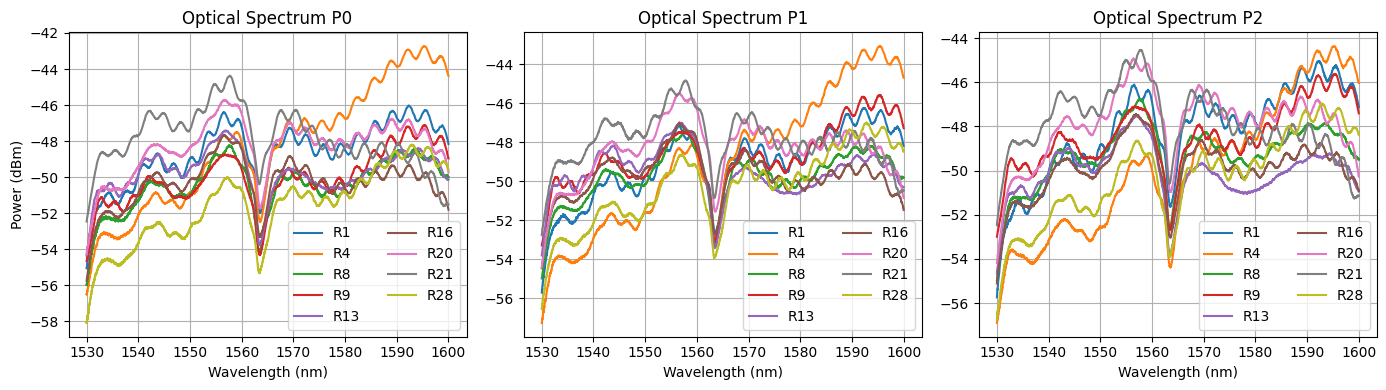

In [22]:
fig, axs = plt.subplots(1, 3, figsize=(14, 4))

axs[0].plot(wavelength_p0_r1, power_p0_r1, label='R1')
axs[0].plot(wavelength_p0_r4, power_p0_r4, label='R4')
axs[0].plot(wavelength_p0_r8, power_p0_r8, label='R8')
axs[0].plot(wavelength_p0_r9, power_p0_r9, label='R9')
axs[0].plot(wavelength_p0_r13, power_p0_r13, label='R13')
axs[0].plot(wavelength_p0_r16, power_p0_r16, label='R16')
axs[0].plot(wavelength_p0_r20, power_p0_r20, label='R20')
axs[0].plot(wavelength_p0_r21, power_p0_r21, label='R21')
axs[0].plot(wavelength_p0_r28, power_p0_r28, label='R28')
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_ylabel("Power (dBm)")
axs[0].set_title("Optical Spectrum P0")
axs[0].legend(ncol=2)
axs[0].grid()

axs[1].plot(wavelength_p1_r1, power_p1_r1, label='R1')
axs[1].plot(wavelength_p1_r4, power_p1_r4, label='R4')
axs[1].plot(wavelength_p1_r8, power_p1_r8, label='R8')
axs[1].plot(wavelength_p1_r9, power_p1_r9, label='R9')
axs[1].plot(wavelength_p1_r13, power_p1_r13, label='R13')
axs[1].plot(wavelength_p1_r16, power_p1_r16, label='R16')
axs[1].plot(wavelength_p1_r20, power_p1_r20, label='R20')
axs[1].plot(wavelength_p1_r21, power_p1_r21, label='R21')
axs[1].plot(wavelength_p1_r28, power_p1_r28, label='R28')
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_title("Optical Spectrum P1")
axs[1].legend(ncol=2)
axs[1].grid()

axs[2].plot(wavelength_p2_r1, power_p2_r1, label='R1')
axs[2].plot(wavelength_p2_r4, power_p2_r4, label='R4')
axs[2].plot(wavelength_p2_r8, power_p2_r8, label='R8')
axs[2].plot(wavelength_p2_r9, power_p2_r9, label='R9')
axs[2].plot(wavelength_p2_r13, power_p2_r13, label='R13')
axs[2].plot(wavelength_p2_r16, power_p2_r16, label='R16')
axs[2].plot(wavelength_p2_r20, power_p2_r20, label='R20')
axs[2].plot(wavelength_p2_r21, power_p2_r21, label='R21')
axs[2].plot(wavelength_p2_r28, power_p2_r28, label='R28')
axs[2].set_xlabel("Wavelength (nm)")
axs[2].set_title("Optical Spectrum P2")
axs[2].legend(ncol=2)
axs[2].grid()

plt.tight_layout()
plt.show()

# MMIs 1x2

## Measured Spectrum

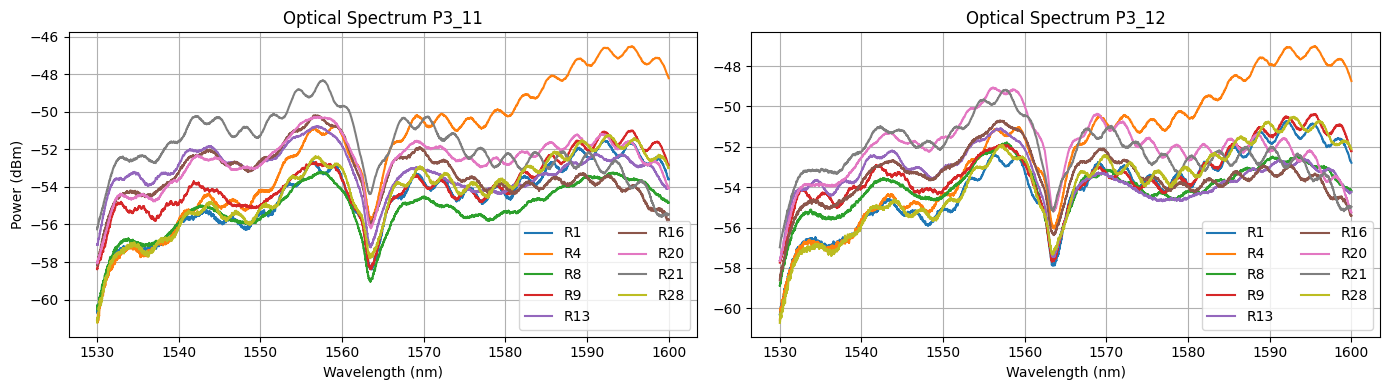

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].plot(wavelength_p3_r1_11, power_p3_r1_11, label='R1')
axs[0].plot(wavelength_p3_r4_11, power_p3_r4_11, label='R4')
axs[0].plot(wavelength_p3_r8_11, power_p3_r8_11, label='R8')
axs[0].plot(wavelength_p3_r9_11, power_p3_r9_11, label='R9')
axs[0].plot(wavelength_p3_r13_11, power_p3_r13_11, label='R13')
axs[0].plot(wavelength_p3_r16_11, power_p3_r16_11, label='R16')
axs[0].plot(wavelength_p3_r20_11, power_p3_r20_11, label='R20')
axs[0].plot(wavelength_p3_r21_11, power_p3_r21_11, label='R21')
axs[0].plot(wavelength_p3_r28_11, power_p3_r28_11, label='R28')
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_ylabel("Power (dBm)")
axs[0].set_title("Optical Spectrum P3_11")
axs[0].legend(ncol=2)
axs[0].grid()

axs[1].plot(wavelength_p3_r1_12, power_p3_r1_12, label='R1')
axs[1].plot(wavelength_p3_r4_12, power_p3_r4_12, label='R4')
axs[1].plot(wavelength_p3_r8_12, power_p3_r8_12, label='R8')
axs[1].plot(wavelength_p3_r9_12, power_p3_r9_12, label='R9')
axs[1].plot(wavelength_p3_r13_12, power_p3_r13_12, label='R13')
axs[1].plot(wavelength_p3_r16_12, power_p3_r16_12, label='R16')
axs[1].plot(wavelength_p3_r20_12, power_p3_r20_12, label='R20')
axs[1].plot(wavelength_p3_r21_12, power_p3_r21_12, label='R21')
axs[1].plot(wavelength_p3_r28_12, power_p3_r28_12, label='R28')
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_title("Optical Spectrum P3_12")
axs[1].legend(ncol=2)
axs[1].grid()

plt.tight_layout()
plt.show()

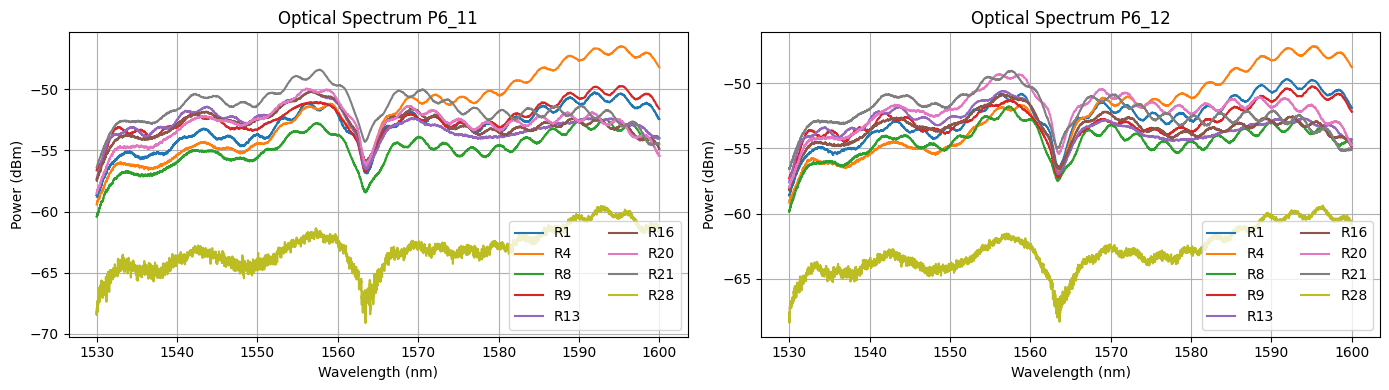

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

axs[0].plot(wavelength_p6_r1_11, power_p6_r1_11, label='R1')
axs[0].plot(wavelength_p6_r4_11, power_p6_r4_11, label='R4')
axs[0].plot(wavelength_p6_r8_11, power_p6_r8_11, label='R8')
axs[0].plot(wavelength_p6_r9_11, power_p6_r9_11, label='R9')
axs[0].plot(wavelength_p6_r13_11, power_p6_r13_11, label='R13')
axs[0].plot(wavelength_p6_r16_11, power_p6_r16_11, label='R16')
axs[0].plot(wavelength_p6_r20_11, power_p6_r20_11, label='R20')
axs[0].plot(wavelength_p6_r21_11, power_p6_r21_11, label='R21')
axs[0].plot(wavelength_p6_r28_11, power_p6_r28_11, label='R28')
axs[0].set_xlabel("Wavelength (nm)")
axs[0].set_ylabel("Power (dBm)")
axs[0].set_title("Optical Spectrum P6_11")
axs[0].legend(ncol=2)
axs[0].grid()

axs[1].plot(wavelength_p6_r1_12, power_p6_r1_12, label='R1')
axs[1].plot(wavelength_p6_r4_12, power_p6_r4_12, label='R4')
axs[1].plot(wavelength_p6_r8_12, power_p6_r8_12, label='R8')
axs[1].plot(wavelength_p6_r9_12, power_p6_r9_12, label='R9')
axs[1].plot(wavelength_p6_r13_12, power_p6_r13_12, label='R13')
axs[1].plot(wavelength_p6_r16_12, power_p6_r16_12, label='R16')
axs[1].plot(wavelength_p6_r20_12, power_p6_r20_12, label='R20')
axs[1].plot(wavelength_p6_r21_12, power_p6_r21_12, label='R21')
axs[1].plot(wavelength_p6_r28_12, power_p6_r28_12, label='R28')
axs[1].set_xlabel("Wavelength (nm)")
axs[1].set_ylabel("Power (dBm)")
axs[1].set_title("Optical Spectrum P6_12")
axs[1].legend(ncol=2)
axs[1].grid()

plt.tight_layout()
plt.show()

## Coupling Coefficients & Losses

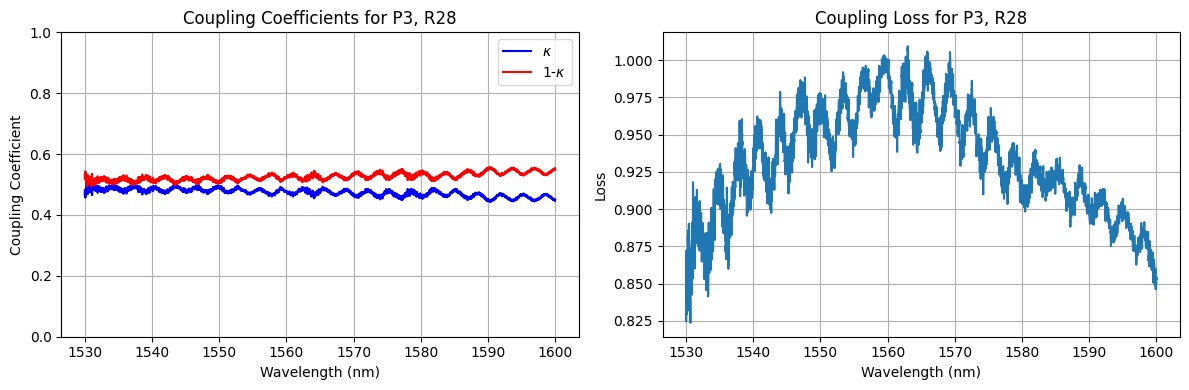

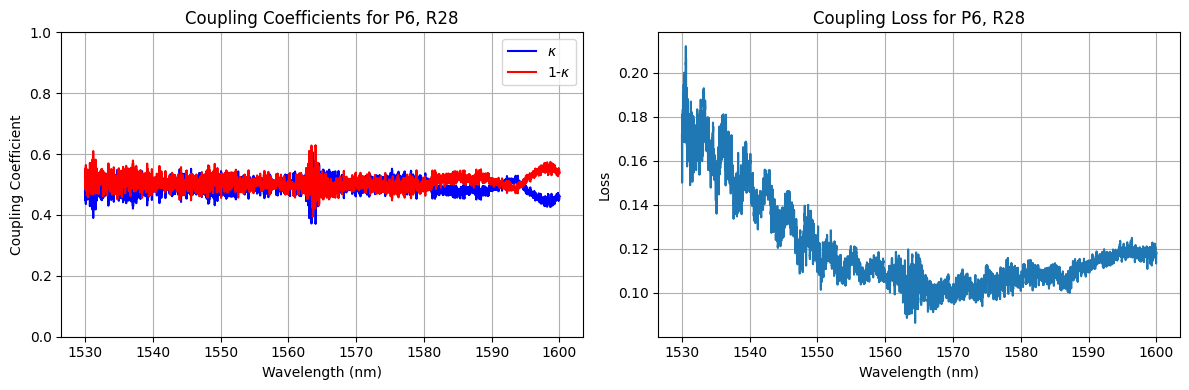

In [25]:
coupling_1x2(wavelength_p3_r28_11, power_p3_r28_11, power_p3_r28_12, [power_p0_r28, power_p1_r28, power_p2_r28], "P3, R28")
coupling_1x2(wavelength_p6_r28_11, power_p6_r28_11, power_p6_r28_12, [power_p0_r28, power_p1_r28, power_p2_r28], "P6, R28")

# MMIs 2x2

## Measured Spectrum

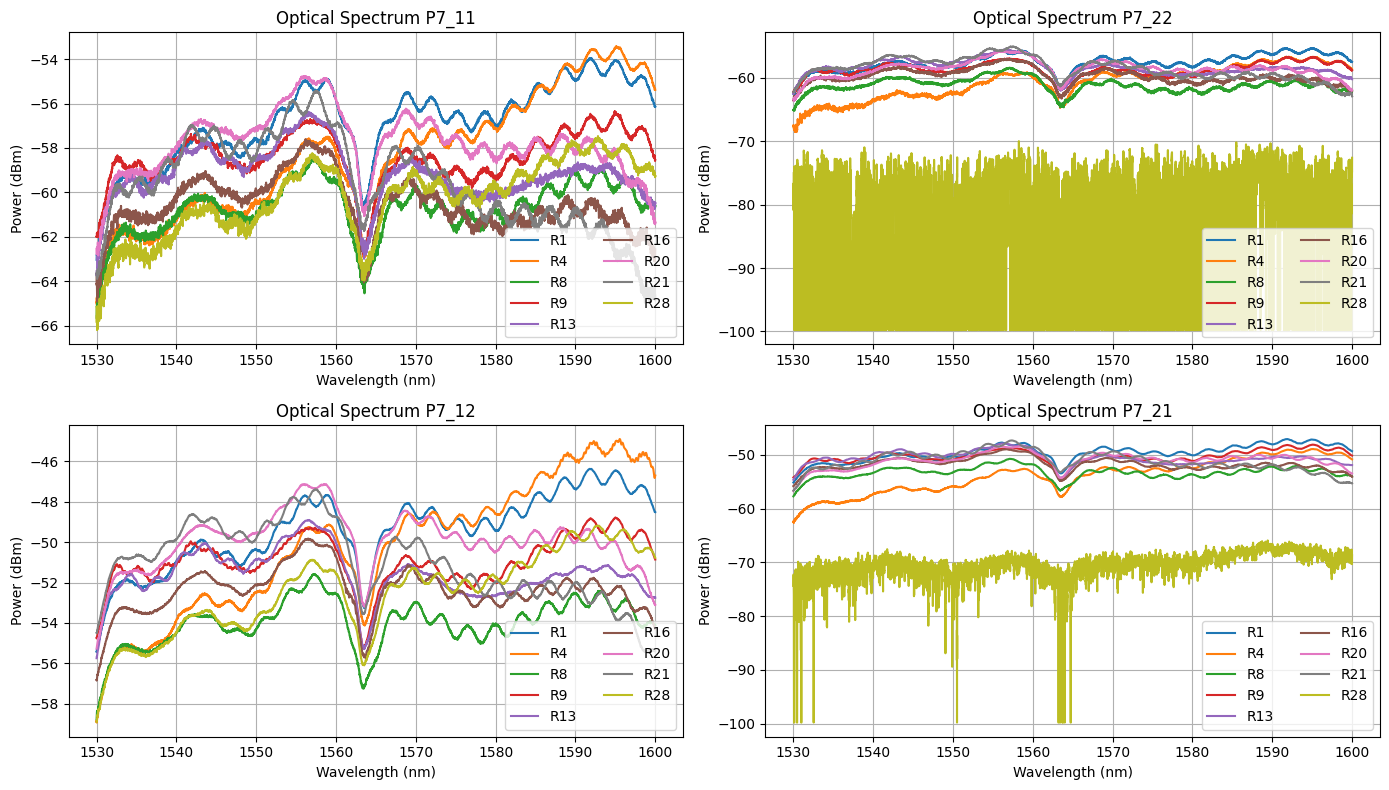

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(wavelength_p7_r1_11, power_p7_r1_11, label='R1')
axs[0, 0].plot(wavelength_p7_r4_11, power_p7_r4_11, label='R4')
axs[0, 0].plot(wavelength_p7_r8_11, power_p7_r8_11, label='R8')
axs[0, 0].plot(wavelength_p7_r9_11, power_p7_r9_11, label='R9')
axs[0, 0].plot(wavelength_p7_r13_11, power_p7_r13_11, label='R13')
axs[0, 0].plot(wavelength_p7_r16_11, power_p7_r16_11, label='R16')
axs[0, 0].plot(wavelength_p7_r20_11, power_p7_r20_11, label='R20')
axs[0, 0].plot(wavelength_p7_r21_11, power_p7_r21_11, label='R21')
axs[0, 0].plot(wavelength_p7_r28_11, power_p7_r28_11, label='R28')
axs[0, 0].set_xlabel("Wavelength (nm)")
axs[0, 0].set_ylabel("Power (dBm)")
axs[0, 0].set_title("Optical Spectrum P7_11")
axs[0, 0].legend(ncol=2)
axs[0, 0].grid()

axs[1, 0].plot(wavelength_p7_r1_12, power_p7_r1_12, label='R1')
axs[1, 0].plot(wavelength_p7_r4_12, power_p7_r4_12, label='R4')
axs[1, 0].plot(wavelength_p7_r8_12, power_p7_r8_12, label='R8')
axs[1, 0].plot(wavelength_p7_r9_12, power_p7_r9_12, label='R9')
axs[1, 0].plot(wavelength_p7_r13_12, power_p7_r13_12, label='R13')
axs[1, 0].plot(wavelength_p7_r16_12, power_p7_r16_12, label='R16')
axs[1, 0].plot(wavelength_p7_r20_12, power_p7_r20_12, label='R20')
axs[1, 0].plot(wavelength_p7_r21_12, power_p7_r21_12, label='R21')
axs[1, 0].plot(wavelength_p7_r28_12, power_p7_r28_12, label='R28')
axs[1, 0].set_xlabel("Wavelength (nm)")
axs[1, 0].set_ylabel("Power (dBm)")
axs[1, 0].set_title("Optical Spectrum P7_12")
axs[1, 0].legend(ncol=2)
axs[1, 0].grid()

axs[0, 1].plot(wavelength_p7_r1_22, power_p7_r1_22, label='R1')
axs[0, 1].plot(wavelength_p7_r4_22, power_p7_r4_22, label='R4')
axs[0, 1].plot(wavelength_p7_r8_22, power_p7_r8_22, label='R8')
axs[0, 1].plot(wavelength_p7_r9_22, power_p7_r9_22, label='R9')
axs[0, 1].plot(wavelength_p7_r13_22, power_p7_r13_22, label='R13')
axs[0, 1].plot(wavelength_p7_r16_22, power_p7_r16_22, label='R16')
axs[0, 1].plot(wavelength_p7_r20_22, power_p7_r20_22, label='R20')
axs[0, 1].plot(wavelength_p7_r21_22, power_p7_r21_22, label='R21')
axs[0, 1].plot(wavelength_p7_r28_22, power_p7_r28_22, label='R28')
axs[0, 1].set_xlabel("Wavelength (nm)")
axs[0, 1].set_ylabel("Power (dBm)")
axs[0, 1].set_title("Optical Spectrum P7_22")
axs[0, 1].legend(ncol=2)
axs[0, 1].grid()

axs[1, 1].plot(wavelength_p7_r1_21, power_p7_r1_21, label='R1')
axs[1, 1].plot(wavelength_p7_r4_21, power_p7_r4_21, label='R4')
axs[1, 1].plot(wavelength_p7_r8_21, power_p7_r8_21, label='R8')
axs[1, 1].plot(wavelength_p7_r9_21, power_p7_r9_21, label='R9')
axs[1, 1].plot(wavelength_p7_r13_21, power_p7_r13_21, label='R13')
axs[1, 1].plot(wavelength_p7_r16_21, power_p7_r16_21, label='R16')
axs[1, 1].plot(wavelength_p7_r20_21, power_p7_r20_21, label='R20')
axs[1, 1].plot(wavelength_p7_r21_21, power_p7_r21_21, label='R21')
axs[1, 1].plot(wavelength_p7_r28_21, power_p7_r28_21, label='R28')
axs[1, 1].set_xlabel("Wavelength (nm)")
axs[1, 1].set_ylabel("Power (dBm)")
axs[1, 1].set_title("Optical Spectrum P7_21")
axs[1, 1].legend(ncol=2)
axs[1, 1].grid()

plt.tight_layout()
plt.show()

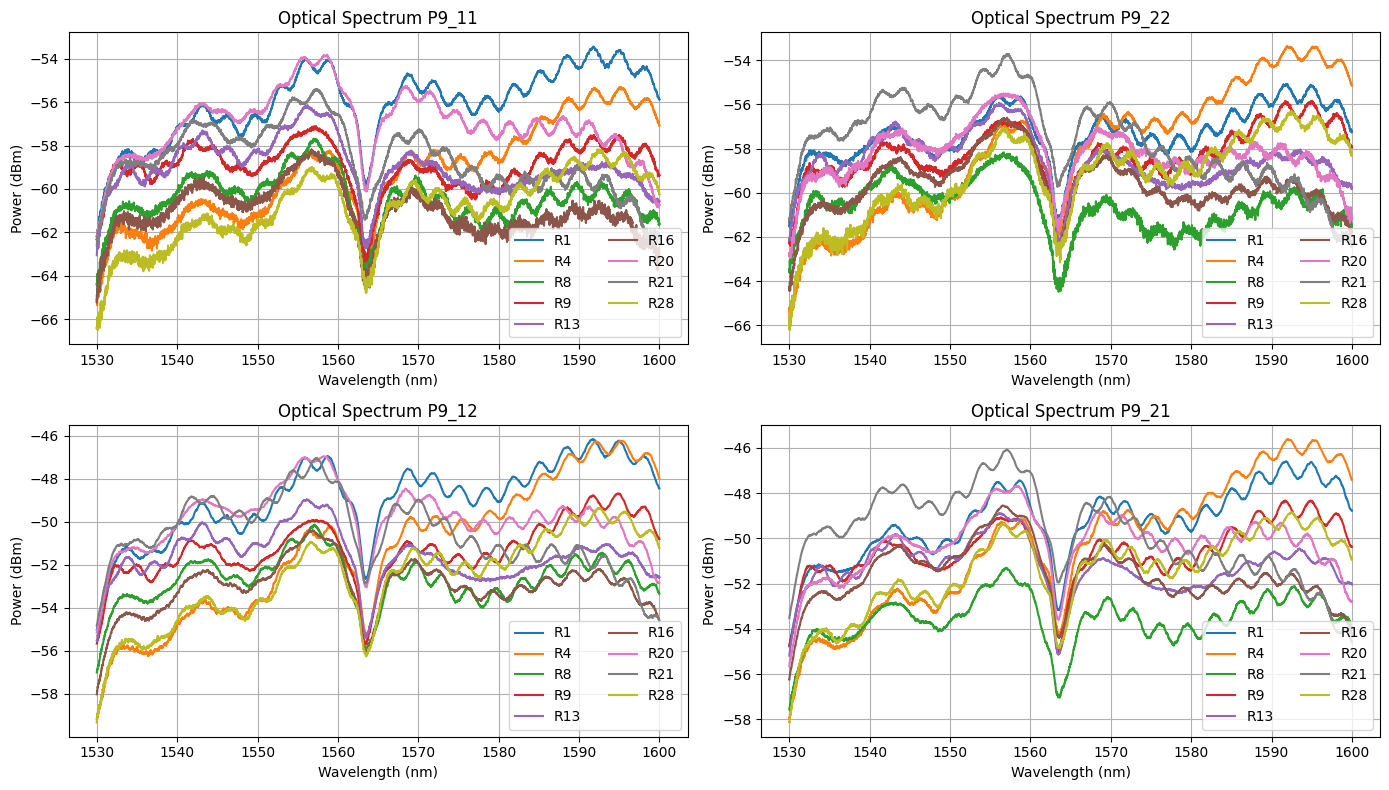

In [27]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(wavelength_p9_r1_11, power_p9_r1_11, label='R1')
axs[0, 0].plot(wavelength_p9_r4_11, power_p9_r4_11, label='R4')
axs[0, 0].plot(wavelength_p9_r8_11, power_p9_r8_11, label='R8')
axs[0, 0].plot(wavelength_p9_r9_11, power_p9_r9_11, label='R9')
axs[0, 0].plot(wavelength_p9_r13_11, power_p9_r13_11, label='R13')
axs[0, 0].plot(wavelength_p9_r16_11, power_p9_r16_11, label='R16')
axs[0, 0].plot(wavelength_p9_r20_11, power_p9_r20_11, label='R20')
axs[0, 0].plot(wavelength_p9_r21_11, power_p9_r21_11, label='R21')
axs[0, 0].plot(wavelength_p9_r28_11, power_p9_r28_11, label='R28')
axs[0, 0].set_xlabel("Wavelength (nm)")
axs[0, 0].set_ylabel("Power (dBm)")
axs[0, 0].set_title("Optical Spectrum P9_11")
axs[0, 0].legend(ncol=2)
axs[0, 0].grid()

axs[1, 0].plot(wavelength_p9_r1_12, power_p9_r1_12, label='R1')
axs[1, 0].plot(wavelength_p9_r4_12, power_p9_r4_12, label='R4')
axs[1, 0].plot(wavelength_p9_r8_12, power_p9_r8_12, label='R8')
axs[1, 0].plot(wavelength_p9_r9_12, power_p9_r9_12, label='R9')
axs[1, 0].plot(wavelength_p9_r13_12, power_p9_r13_12, label='R13')
axs[1, 0].plot(wavelength_p9_r16_12, power_p9_r16_12, label='R16')
axs[1, 0].plot(wavelength_p9_r20_12, power_p9_r20_12, label='R20')
axs[1, 0].plot(wavelength_p9_r21_12, power_p9_r21_12, label='R21')
axs[1, 0].plot(wavelength_p9_r28_12, power_p9_r28_12, label='R28')
axs[1, 0].set_xlabel("Wavelength (nm)")
axs[1, 0].set_ylabel("Power (dBm)")
axs[1, 0].set_title("Optical Spectrum P9_12")
axs[1, 0].legend(ncol=2)
axs[1, 0].grid()

axs[0, 1].plot(wavelength_p9_r1_22, power_p9_r1_22, label='R1')
axs[0, 1].plot(wavelength_p9_r4_22, power_p9_r4_22, label='R4')
axs[0, 1].plot(wavelength_p9_r8_22, power_p9_r8_22, label='R8')
axs[0, 1].plot(wavelength_p9_r9_22, power_p9_r9_22, label='R9')
axs[0, 1].plot(wavelength_p9_r13_22, power_p9_r13_22, label='R13')
axs[0, 1].plot(wavelength_p9_r16_22, power_p9_r16_22, label='R16')
axs[0, 1].plot(wavelength_p9_r20_22, power_p9_r20_22, label='R20')
axs[0, 1].plot(wavelength_p9_r21_22, power_p9_r21_22, label='R21')
axs[0, 1].plot(wavelength_p9_r28_22, power_p9_r28_22, label='R28')
axs[0, 1].set_xlabel("Wavelength (nm)")
axs[0, 1].set_ylabel("Power (dBm)")
axs[0, 1].set_title("Optical Spectrum P9_22")
axs[0, 1].legend(ncol=2)
axs[0, 1].grid()

axs[1, 1].plot(wavelength_p9_r1_21, power_p9_r1_21, label='R1')
axs[1, 1].plot(wavelength_p9_r4_21, power_p9_r4_21, label='R4')
axs[1, 1].plot(wavelength_p9_r8_21, power_p9_r8_21, label='R8')
axs[1, 1].plot(wavelength_p9_r9_21, power_p9_r9_21, label='R9')
axs[1, 1].plot(wavelength_p9_r13_21, power_p9_r13_21, label='R13')
axs[1, 1].plot(wavelength_p9_r16_21, power_p9_r16_21, label='R16')
axs[1, 1].plot(wavelength_p9_r20_21, power_p9_r20_21, label='R20')
axs[1, 1].plot(wavelength_p9_r21_21, power_p9_r21_21, label='R21')
axs[1, 1].plot(wavelength_p9_r28_21, power_p9_r28_21, label='R28')
axs[1, 1].set_xlabel("Wavelength (nm)")
axs[1, 1].set_ylabel("Power (dBm)")
axs[1, 1].set_title("Optical Spectrum P9_21")
axs[1, 1].legend(ncol=2)
axs[1, 1].grid()

plt.tight_layout()
plt.show()

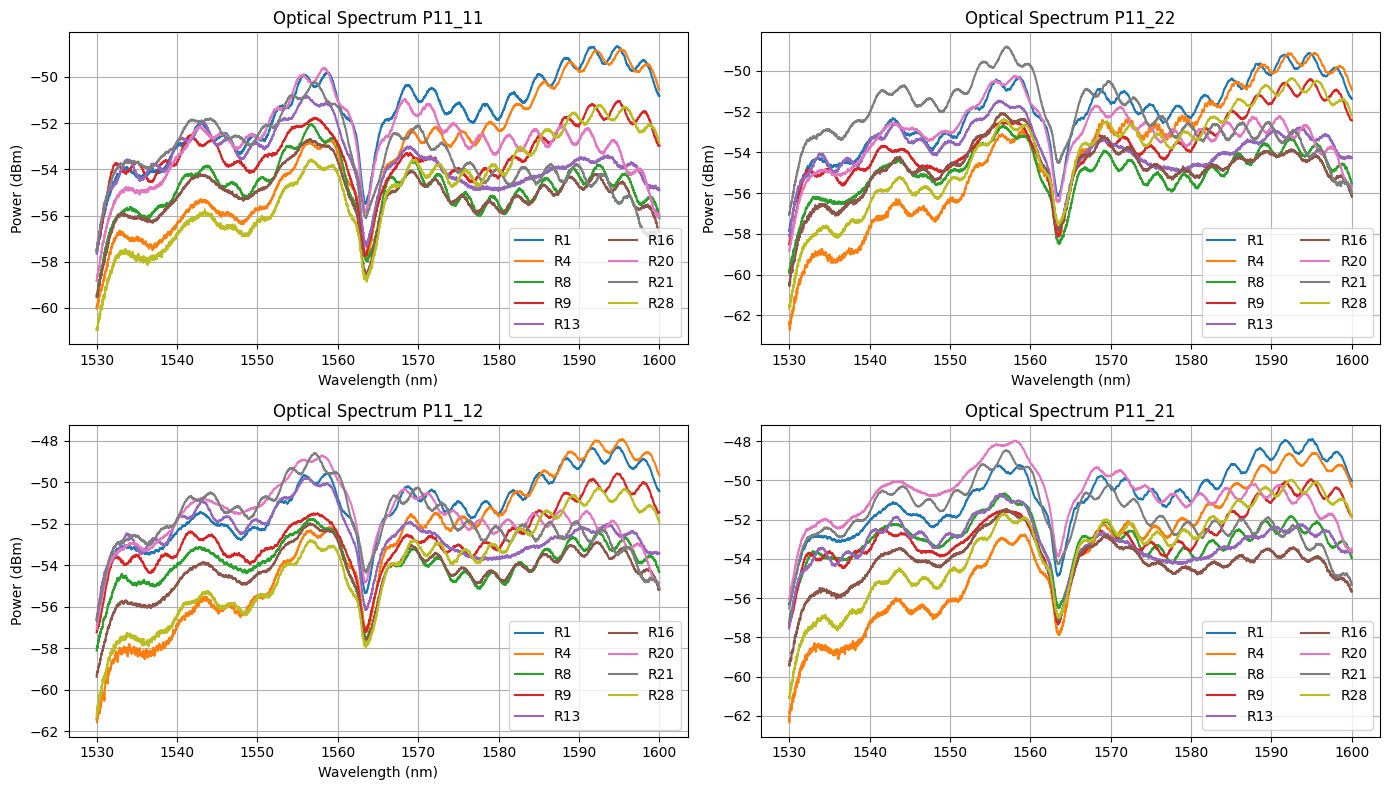

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(wavelength_p11_r1_11, power_p11_r1_11, label='R1')
axs[0, 0].plot(wavelength_p11_r4_11, power_p11_r4_11, label='R4')
axs[0, 0].plot(wavelength_p11_r8_11, power_p11_r8_11, label='R8')
axs[0, 0].plot(wavelength_p11_r9_11, power_p11_r9_11, label='R9')
axs[0, 0].plot(wavelength_p11_r13_11, power_p11_r13_11, label='R13')
axs[0, 0].plot(wavelength_p11_r16_11, power_p11_r16_11, label='R16')
axs[0, 0].plot(wavelength_p11_r20_11, power_p11_r20_11, label='R20')
axs[0, 0].plot(wavelength_p11_r21_11, power_p11_r21_11, label='R21')
axs[0, 0].plot(wavelength_p11_r28_11, power_p11_r28_11, label='R28')
axs[0, 0].set_xlabel("Wavelength (nm)")
axs[0, 0].set_ylabel("Power (dBm)")
axs[0, 0].set_title("Optical Spectrum P11_11")
axs[0, 0].legend(ncol=2)
axs[0, 0].grid()

axs[1, 0].plot(wavelength_p11_r1_12, power_p11_r1_12, label='R1')
axs[1, 0].plot(wavelength_p11_r4_12, power_p11_r4_12, label='R4')
axs[1, 0].plot(wavelength_p11_r8_12, power_p11_r8_12, label='R8')
axs[1, 0].plot(wavelength_p11_r9_12, power_p11_r9_12, label='R9')
axs[1, 0].plot(wavelength_p11_r13_12, power_p11_r13_12, label='R13')
axs[1, 0].plot(wavelength_p11_r16_12, power_p11_r16_12, label='R16')
axs[1, 0].plot(wavelength_p11_r20_12, power_p11_r20_12, label='R20')
axs[1, 0].plot(wavelength_p11_r21_12, power_p11_r21_12, label='R21')
axs[1, 0].plot(wavelength_p11_r28_12, power_p11_r28_12, label='R28')
axs[1, 0].set_xlabel("Wavelength (nm)")
axs[1, 0].set_ylabel("Power (dBm)")
axs[1, 0].set_title("Optical Spectrum P11_12")
axs[1, 0].legend(ncol=2)
axs[1, 0].grid()

axs[0, 1].plot(wavelength_p11_r1_22, power_p11_r1_22, label='R1')
axs[0, 1].plot(wavelength_p11_r4_22, power_p11_r4_22, label='R4')
axs[0, 1].plot(wavelength_p11_r8_22, power_p11_r8_22, label='R8')
axs[0, 1].plot(wavelength_p11_r9_22, power_p11_r9_22, label='R9')
axs[0, 1].plot(wavelength_p11_r13_22, power_p11_r13_22, label='R13')
axs[0, 1].plot(wavelength_p11_r16_22, power_p11_r16_22, label='R16')
axs[0, 1].plot(wavelength_p11_r20_22, power_p11_r20_22, label='R20')
axs[0, 1].plot(wavelength_p11_r21_22, power_p11_r21_22, label='R21')
axs[0, 1].plot(wavelength_p11_r28_22, power_p11_r28_22, label='R28')
axs[0, 1].set_xlabel("Wavelength (nm)")
axs[0, 1].set_ylabel("Power (dBm)")
axs[0, 1].set_title("Optical Spectrum P11_22")
axs[0, 1].legend(ncol=2)
axs[0, 1].grid()

axs[1, 1].plot(wavelength_p11_r1_21, power_p11_r1_21, label='R1')
axs[1, 1].plot(wavelength_p11_r4_21, power_p11_r4_21, label='R4')
axs[1, 1].plot(wavelength_p11_r8_21, power_p11_r8_21, label='R8')
axs[1, 1].plot(wavelength_p11_r9_21, power_p11_r9_21, label='R9')
axs[1, 1].plot(wavelength_p11_r13_21, power_p11_r13_21, label='R13')
axs[1, 1].plot(wavelength_p11_r16_21, power_p11_r16_21, label='R16')
axs[1, 1].plot(wavelength_p11_r20_21, power_p11_r20_21, label='R20')
axs[1, 1].plot(wavelength_p11_r21_21, power_p11_r21_21, label='R21')
axs[1, 1].plot(wavelength_p11_r28_21, power_p11_r28_21, label='R28')
axs[1, 1].set_title("Optical Spectrum P11_21")
axs[1, 1].legend(ncol=2)
axs[1, 1].grid()

plt.tight_layout()
plt.show()

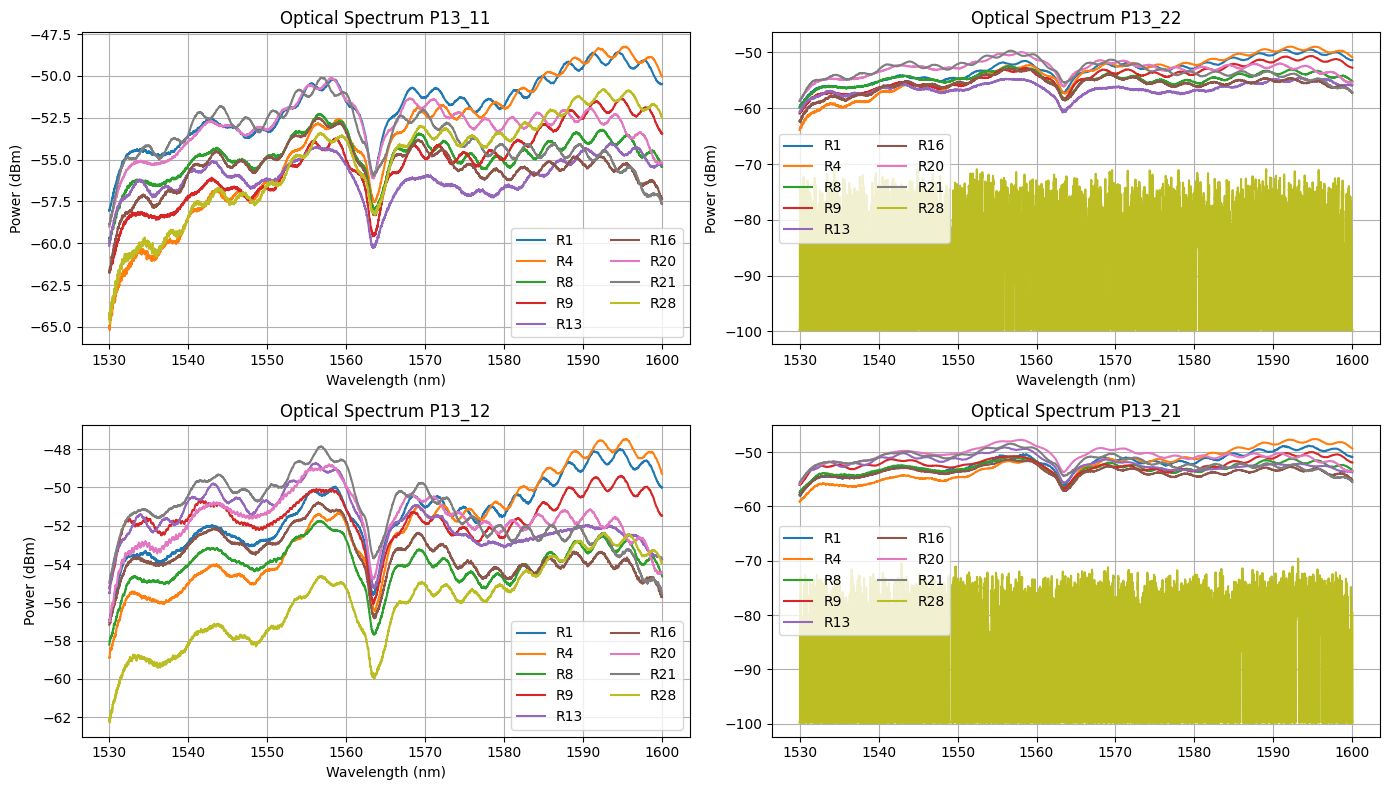

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

axs[0, 0].plot(wavelength_p13_r1_11, power_p13_r1_11, label='R1')
axs[0, 0].plot(wavelength_p13_r4_11, power_p13_r4_11, label='R4')
axs[0, 0].plot(wavelength_p13_r8_11, power_p13_r8_11, label='R8')
axs[0, 0].plot(wavelength_p13_r9_11, power_p13_r9_11, label='R9')
axs[0, 0].plot(wavelength_p13_r13_11, power_p13_r13_11, label='R13')
axs[0, 0].plot(wavelength_p13_r16_11, power_p13_r16_11, label='R16')
axs[0, 0].plot(wavelength_p13_r20_11, power_p13_r20_11, label='R20')
axs[0, 0].plot(wavelength_p13_r21_11, power_p13_r21_11, label='R21')
axs[0, 0].plot(wavelength_p13_r28_11, power_p13_r28_11, label='R28')
axs[0, 0].set_xlabel("Wavelength (nm)")
axs[0, 0].set_ylabel("Power (dBm)")
axs[0, 0].set_title("Optical Spectrum P13_11")
axs[0, 0].legend(ncol=2)
axs[0, 0].grid()

axs[1, 0].plot(wavelength_p13_r1_12, power_p13_r1_12, label='R1')
axs[1, 0].plot(wavelength_p13_r4_12, power_p13_r4_12, label='R4')
axs[1, 0].plot(wavelength_p13_r8_12, power_p13_r8_12, label='R8')
axs[1, 0].plot(wavelength_p13_r9_12, power_p13_r9_12, label='R9')
axs[1, 0].plot(wavelength_p13_r13_12, power_p13_r13_12, label='R13')
axs[1, 0].plot(wavelength_p13_r16_12, power_p13_r16_12, label='R16')
axs[1, 0].plot(wavelength_p13_r20_12, power_p13_r20_12, label='R20')
axs[1, 0].plot(wavelength_p13_r21_12, power_p13_r21_12, label='R21')
axs[1, 0].plot(wavelength_p13_r28_12, power_p13_r28_12, label='R28')
axs[1, 0].set_xlabel("Wavelength (nm)")
axs[1, 0].set_ylabel("Power (dBm)")
axs[1, 0].set_title("Optical Spectrum P13_12")
axs[1, 0].legend(ncol=2)
axs[1, 0].grid()

axs[0, 1].plot(wavelength_p13_r1_22, power_p13_r1_22, label='R1')
axs[0, 1].plot(wavelength_p13_r4_22, power_p13_r4_22, label='R4')
axs[0, 1].plot(wavelength_p13_r8_22, power_p13_r8_22, label='R8')
axs[0, 1].plot(wavelength_p13_r9_22, power_p13_r9_22, label='R9')
axs[0, 1].plot(wavelength_p13_r13_22, power_p13_r13_22, label='R13')
axs[0, 1].plot(wavelength_p13_r16_22, power_p13_r16_22, label='R16')
axs[0, 1].plot(wavelength_p13_r20_22, power_p13_r20_22, label='R20')
axs[0, 1].plot(wavelength_p13_r21_22, power_p13_r21_22, label='R21')
axs[0, 1].plot(wavelength_p13_r28_22, power_p13_r28_22, label='R28')
axs[0, 1].set_xlabel("Wavelength (nm)")
axs[0, 1].set_ylabel("Power (dBm)")
axs[0, 1].set_title("Optical Spectrum P13_22")
axs[0, 1].legend(ncol=2)
axs[0, 1].grid()

axs[1, 1].plot(wavelength_p13_r1_21, power_p13_r1_21, label='R1')
axs[1, 1].plot(wavelength_p13_r4_21, power_p13_r4_21, label='R4')
axs[1, 1].plot(wavelength_p13_r8_21, power_p13_r8_21, label='R8')
axs[1, 1].plot(wavelength_p13_r9_21, power_p13_r9_21, label='R9')
axs[1, 1].plot(wavelength_p13_r13_21, power_p13_r13_21, label='R13')
axs[1, 1].plot(wavelength_p13_r16_21, power_p13_r16_21, label='R16')
axs[1, 1].plot(wavelength_p13_r20_21, power_p13_r20_21, label='R20')
axs[1, 1].plot(wavelength_p13_r21_21, power_p13_r21_21, label='R21')
axs[1, 1].plot(wavelength_p13_r28_21, power_p13_r28_21, label='R28')
axs[1, 1].set_title("Optical Spectrum P13_21")
axs[1, 1].legend(ncol=2)
axs[1, 1].grid()

plt.tight_layout()
plt.show()

## Coupling Coefficients & Losses

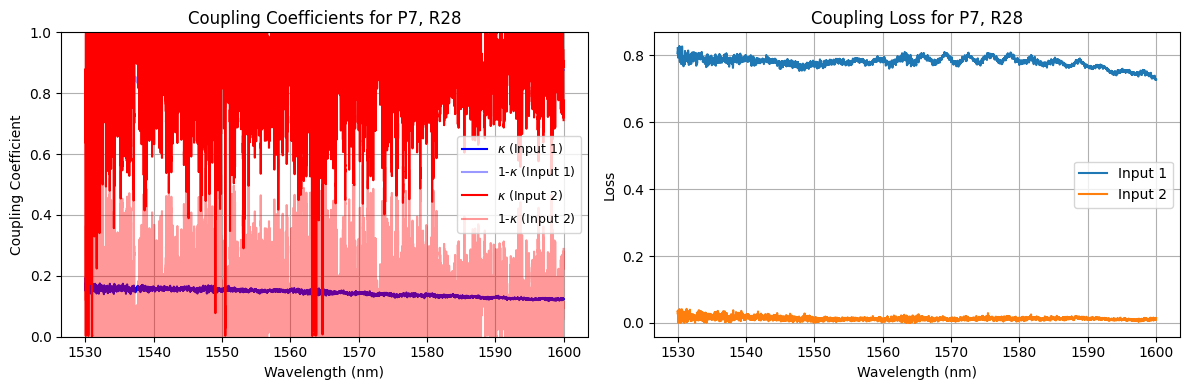

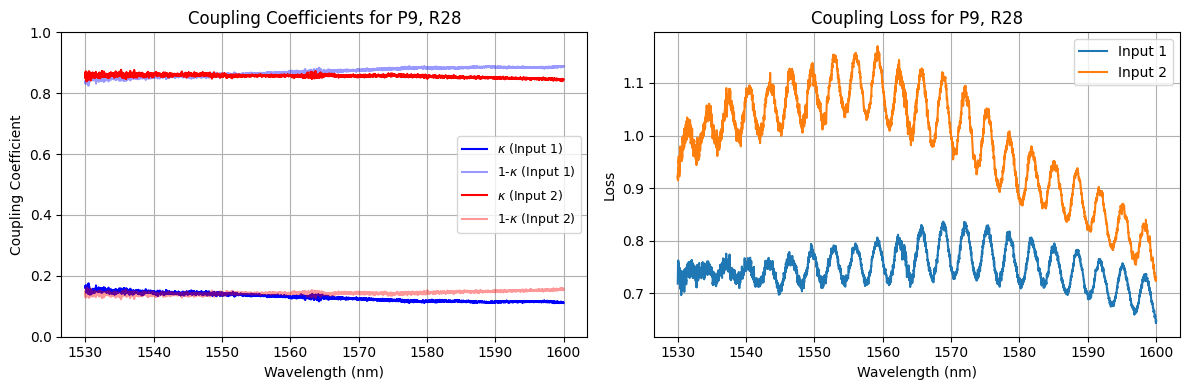

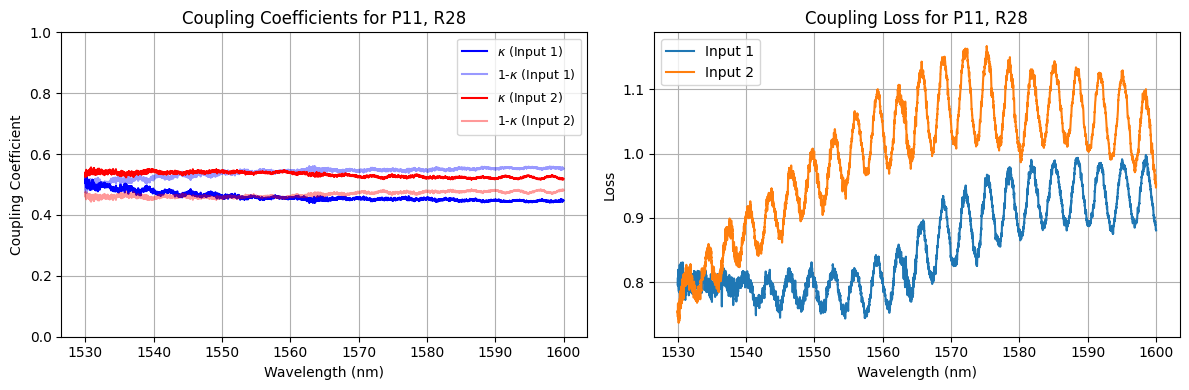

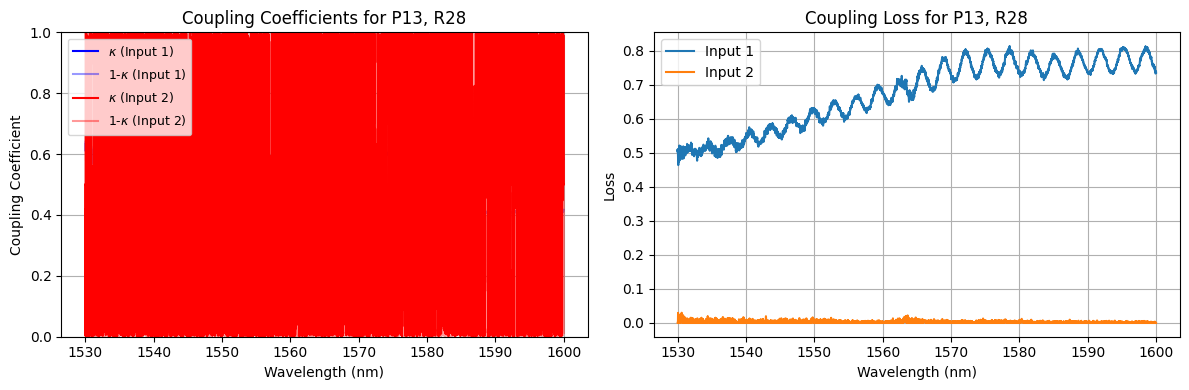

In [30]:
coupling_2x2(wavelength_p7_r28_11, power_p7_r28_11, power_p7_r28_12, power_p7_r28_21, power_p7_r28_22, [power_p0_r28, power_p1_r28, power_p2_r28], "P7, R28")
coupling_2x2(wavelength_p9_r28_11, power_p9_r28_11, power_p9_r28_12, power_p9_r28_21, power_p9_r28_22, [power_p0_r28, power_p1_r28, power_p2_r28], "P9, R28")
coupling_2x2(wavelength_p11_r28_11, power_p11_r28_11, power_p11_r28_12, power_p11_r28_21, power_p11_r28_22, [power_p0_r28, power_p1_r28, power_p2_r28], "P11, R28")
coupling_2x2(wavelength_p13_r28_11, power_p13_r28_11, power_p13_r28_12, power_p13_r28_21, power_p13_r28_22, [power_p0_r28, power_p1_r28, power_p2_r28], "P13, R28")